# Exaploratory Analysis for -------'s Odyssey

### [—————————————pipeline—————————————]
### »——raw—»—clean—»—normalize—»—dataframe——»—EDA—»


I'm taking the csv from the dataframer step into a Pandas dataframe.

## Flow:

* Libraries, directories and text
* Distribution of Lexical Features
* Custom and Customizable Tokenizer Pipeline
* Most Frequent and Keywords
    - counter
    - wordclouds
    - IDF
    - Keyword Window
    - Lineplots
    - Heatmaps
* 

## Libraries, directories and text

In [26]:
import numpy as np
import pandas as pd

from tqdm.notebook import tqdm
import re
tqdm.pandas()

import re
import nltk

import os

In [27]:
import sys
sys.path.append('/Users/debr/English-Homer') 
import bard_visualization as viz# This will apply the visualization settings

In [28]:
# TO UPDATE
translator = "Fagles"

# Paths
filepath = f"/Users/debr/odysseys_en/Odyssey_dfs/Odyssey_{translator}_eda.csv"
output_path_plots = f"/Users/debr/English-Homer/EDA_by_Author/{translator}_EDA/plots/"
os.makedirs(os.path.dirname(output_path_plots), exist_ok=True)

# Load
df = pd.read_csv(filepath)

# Check
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   author         24 non-null     object
 1   year           24 non-null     int64 
 2   title          24 non-null     object
 3   book_num       24 non-null     int64 
 4   text           24 non-null     object
 5   num_lines      24 non-null     int64 
 6   num_sentences  24 non-null     int64 
 7   num_words      24 non-null     int64 
dtypes: int64(5), object(3)
memory usage: 1.6+ KB


## Distribution of Lexical Features

To understand the structural composition of The Odyssey, let's analyze the distribution of the blocks of the text: words, lines, sentences.

**Stacked Line Plot – Spread of Features Across Books**
* A stacked visualization of words, sentences, and lines across books provides a clear view of how these features vary throughout the text.
* This helps identify trends in narrative structure, such as sections with higher density of words or shorter sentences, which may indicate shifts in tone or pacing.

**Kernel Density Approximation (KDA) – Probability Distribution**
* KDA estimates the probability density function (PDF) of lexical features, condensing their distribution into a single plot.
	- Highlights anomalies (e.g., sections with extreme sentence or word counts).
	- Shows overlapping distributions, revealing relationships between words, sentences, and lines.
	- Helps smooth out discrete data for better visualization of trends.

The stacked line plot provides a book-by-book breakdown, useful for seeing structural variation over the narrative. The KDA plot gives a global view of feature distributions, helping identify outliers and stylistic patterns.    

In [29]:
# Fit features to the same scale

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['scaled_num_words', 'scaled_num_sentences', 'scaled_num_lines']] = scaler.fit_transform(df[['num_words', 'num_sentences', 'num_lines']])

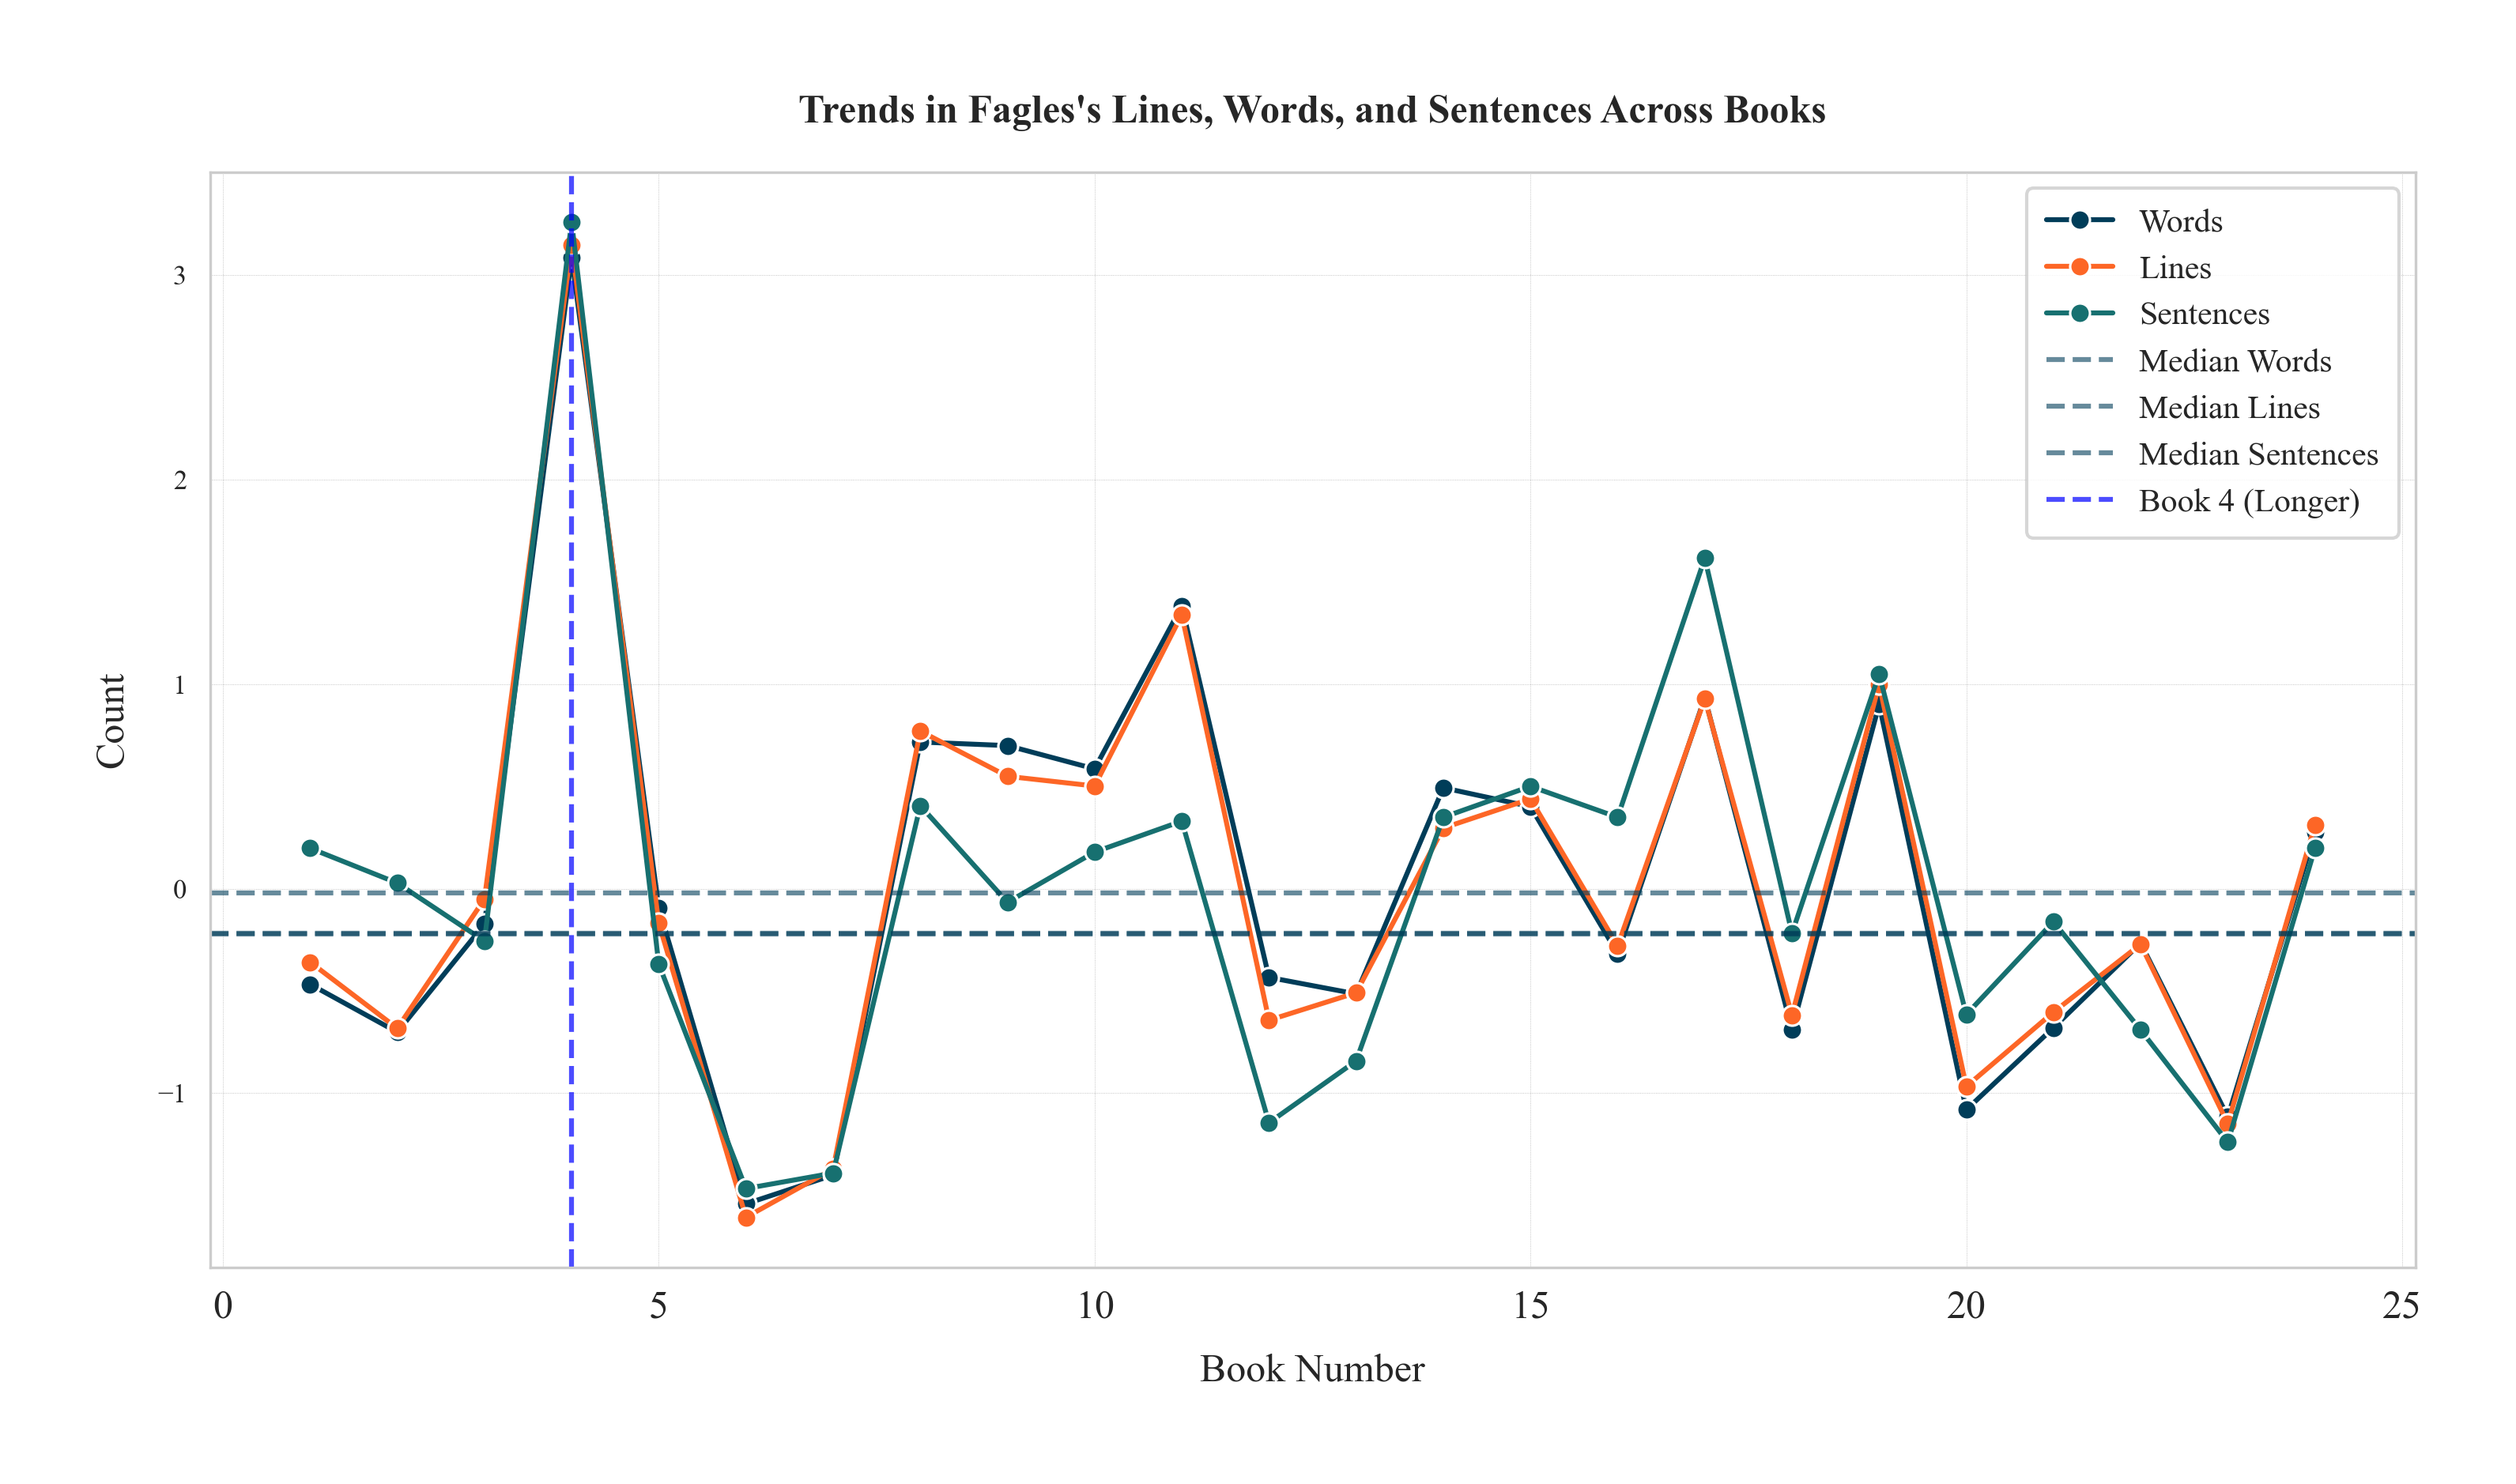

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Plot lines, words, and sentences across books
sns.lineplot(x=df["book_num"], y=df["scaled_num_words"], label="Words", marker="o") #, color="#fcc921"
sns.lineplot(x=df["book_num"], y=df["scaled_num_lines"], label="Lines", marker="o") #, color="#86C3BC"
sns.lineplot(x=df["book_num"], y=df["scaled_num_sentences"], label="Sentences", marker="o") #, color="#FD6626"

# Compute medians
median_words = df["scaled_num_words"].median()
median_lines = df["scaled_num_lines"].median()
median_sentences = df["scaled_num_sentences"].median()

# Add horizontal median lines
plt.axhline(y=median_words, linestyle="--", alpha=0.6, label="Median Words")
plt.axhline(y=median_lines, linestyle="--", alpha=0.6, label="Median Lines")
plt.axhline(y=median_sentences, linestyle="--", alpha=0.6, label="Median Sentences")

# Highlight Book 4
plt.axvline(x=4, color='blue', linestyle='--', alpha=0.7, label="Book 4 (Longer)")

# Labels and legend
plt.xlabel("Book Number")
plt.ylabel("Count")
plt.title(f"Trends in {translator}'s Lines, Words, and Sentences Across Books")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(f"{output_path_plots}/{translator}-Trends_Lines_Words_Sentences.png")
plt.show()

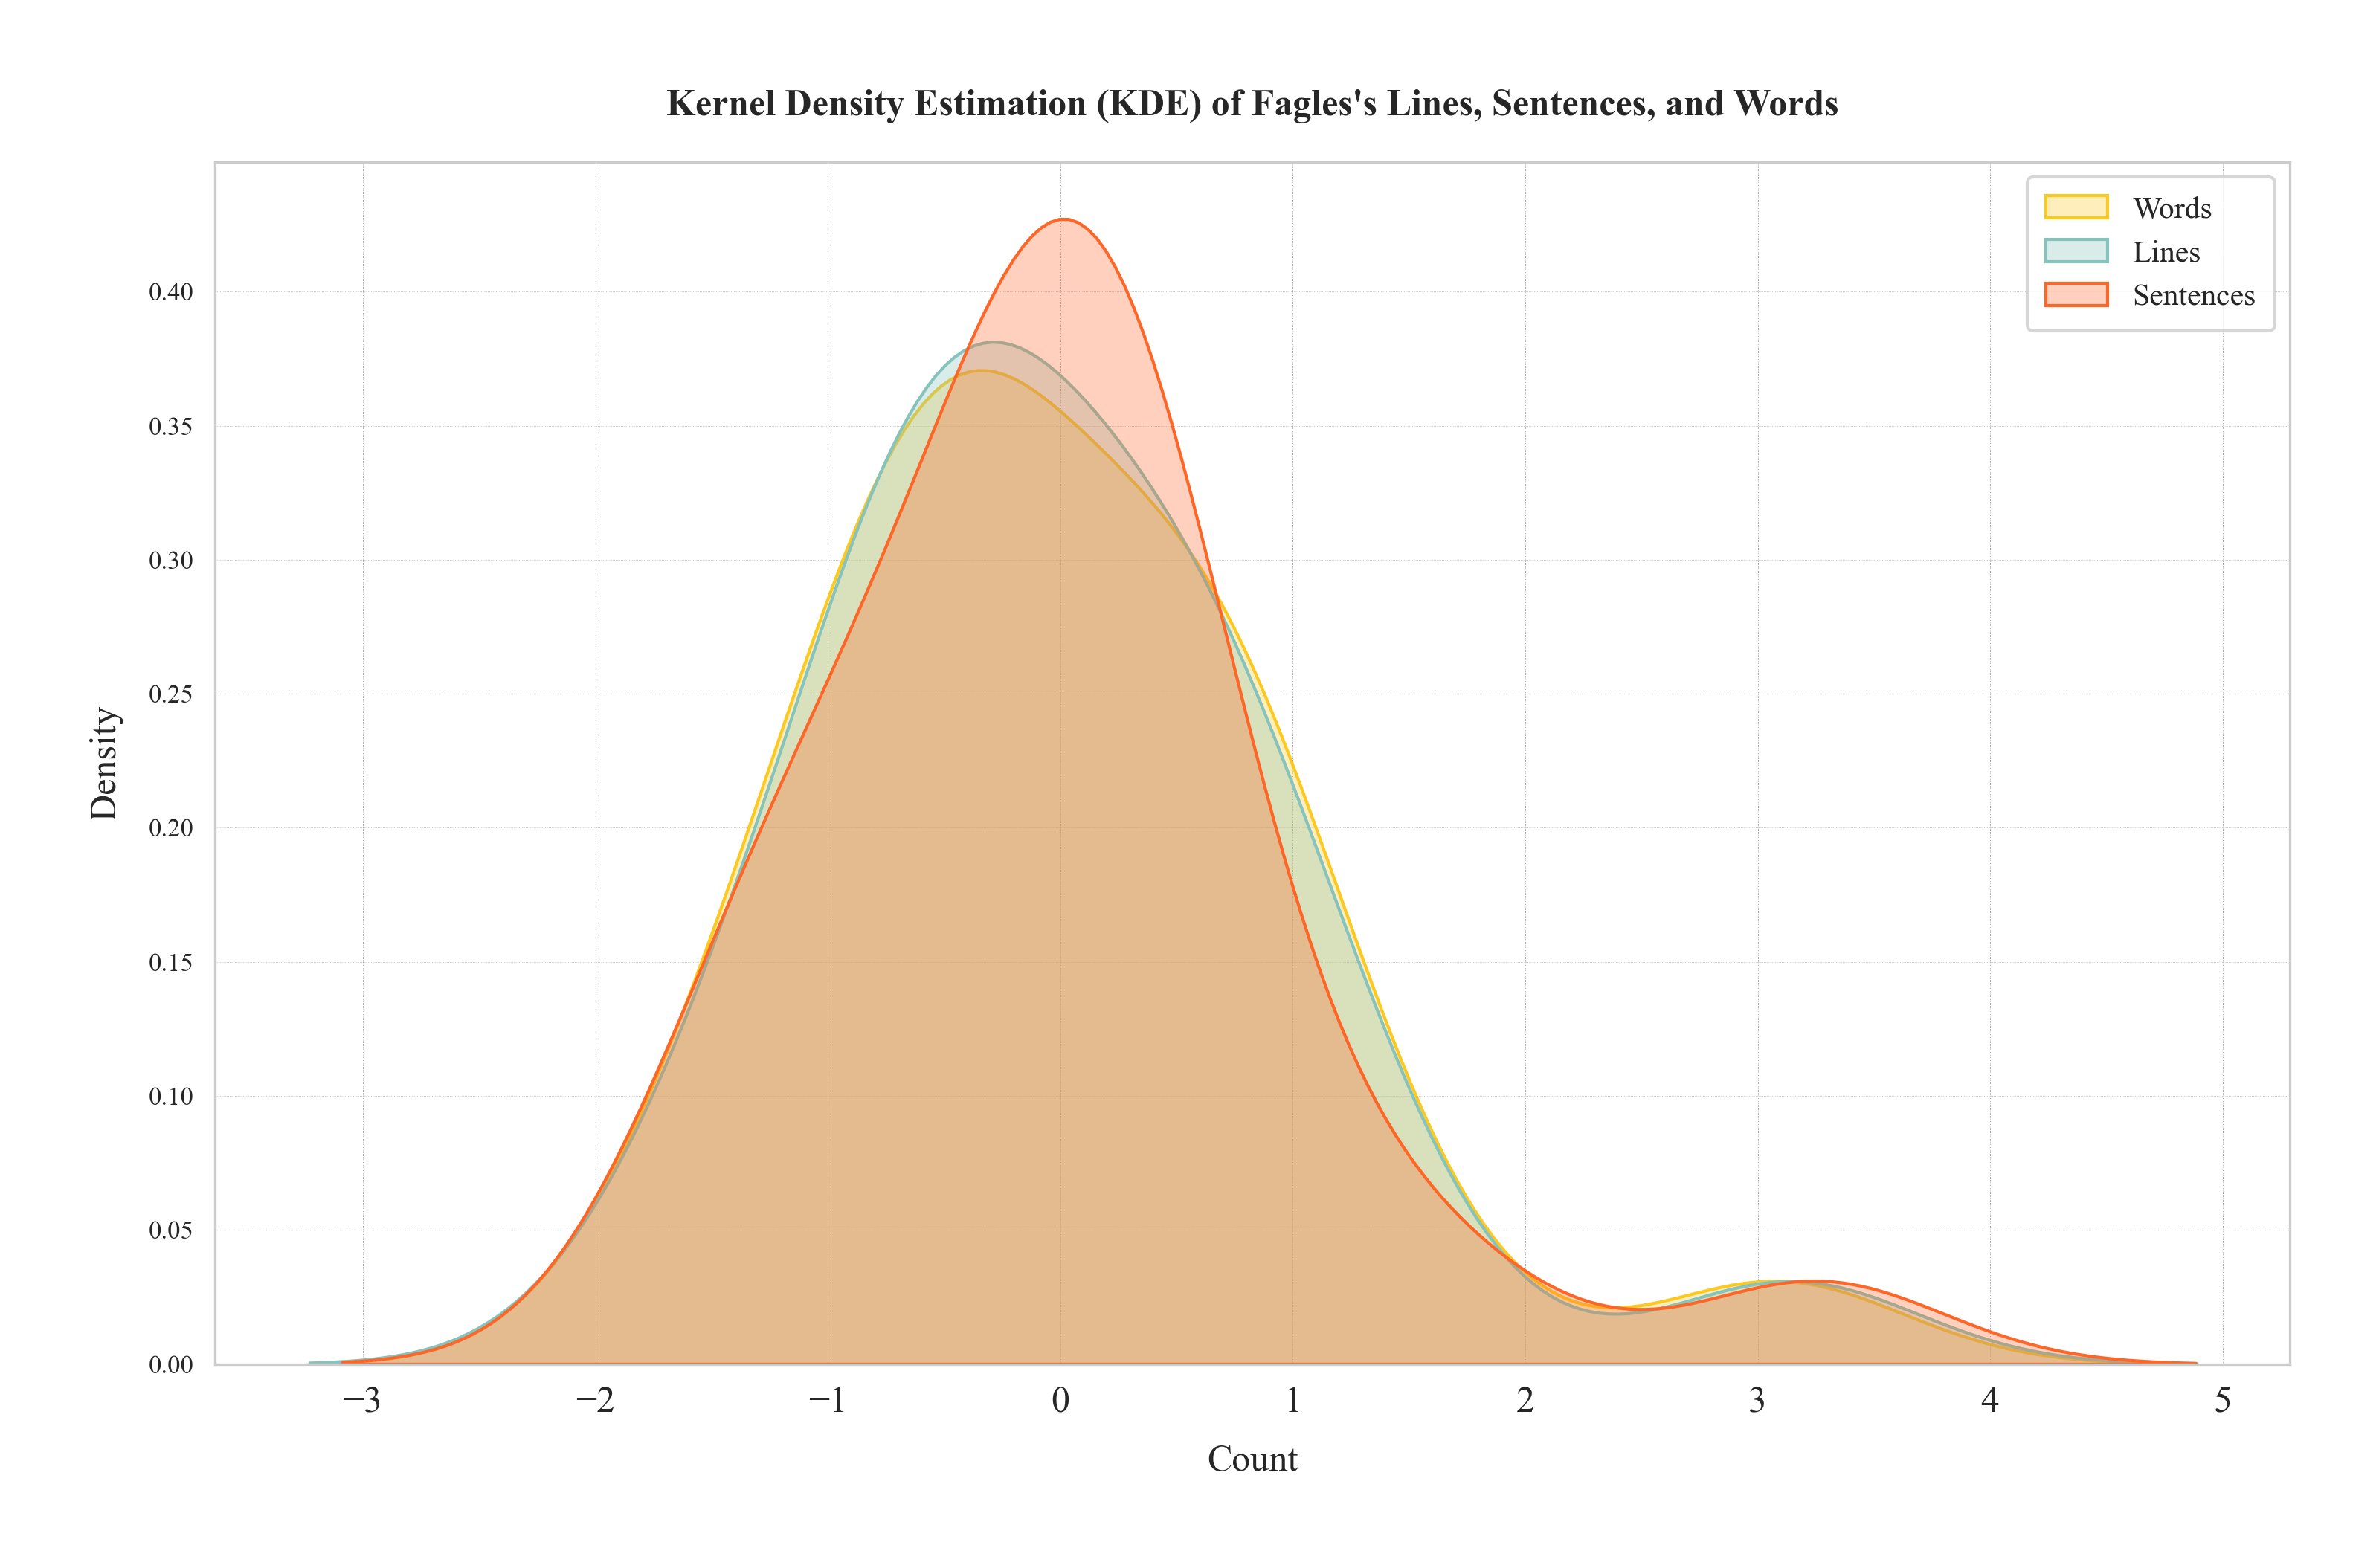

In [31]:
# KDE plot for Lines, Sentences, and Words
sns.kdeplot(df['scaled_num_words'], label="Words", color= "#fcc921", fill=True, alpha=0.3)
sns.kdeplot(df['scaled_num_lines'], label="Lines", color='#86C3BC', fill=True, alpha=0.3)
sns.kdeplot(df['scaled_num_sentences'], label="Sentences", color='#FD6626',fill=True, alpha=0.3)

plt.xlabel("Count")
plt.ylabel("Density")
plt.title(f"Kernel Density Estimation (KDE) of {translator}'s Lines, Sentences, and Words")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig(f"{output_path_plots}/{translator}-KDE_Lines_Sentences_Words.png")
plt.show()

**Interpretation:**

The general trend, and expectation, is that words and lines follow each other distribution, while there is some variation in sentence lenght. This is to be expected because words and lines are more constrained than sentences, which vary depending on narrative function (dialog, action, formulaic verse, etc) and style. 

The scatter plot bellow give another perspective of the distribution whille highlighting the distance of Book Fourth from the rest. and the boxplots show outliers individualy, if any.

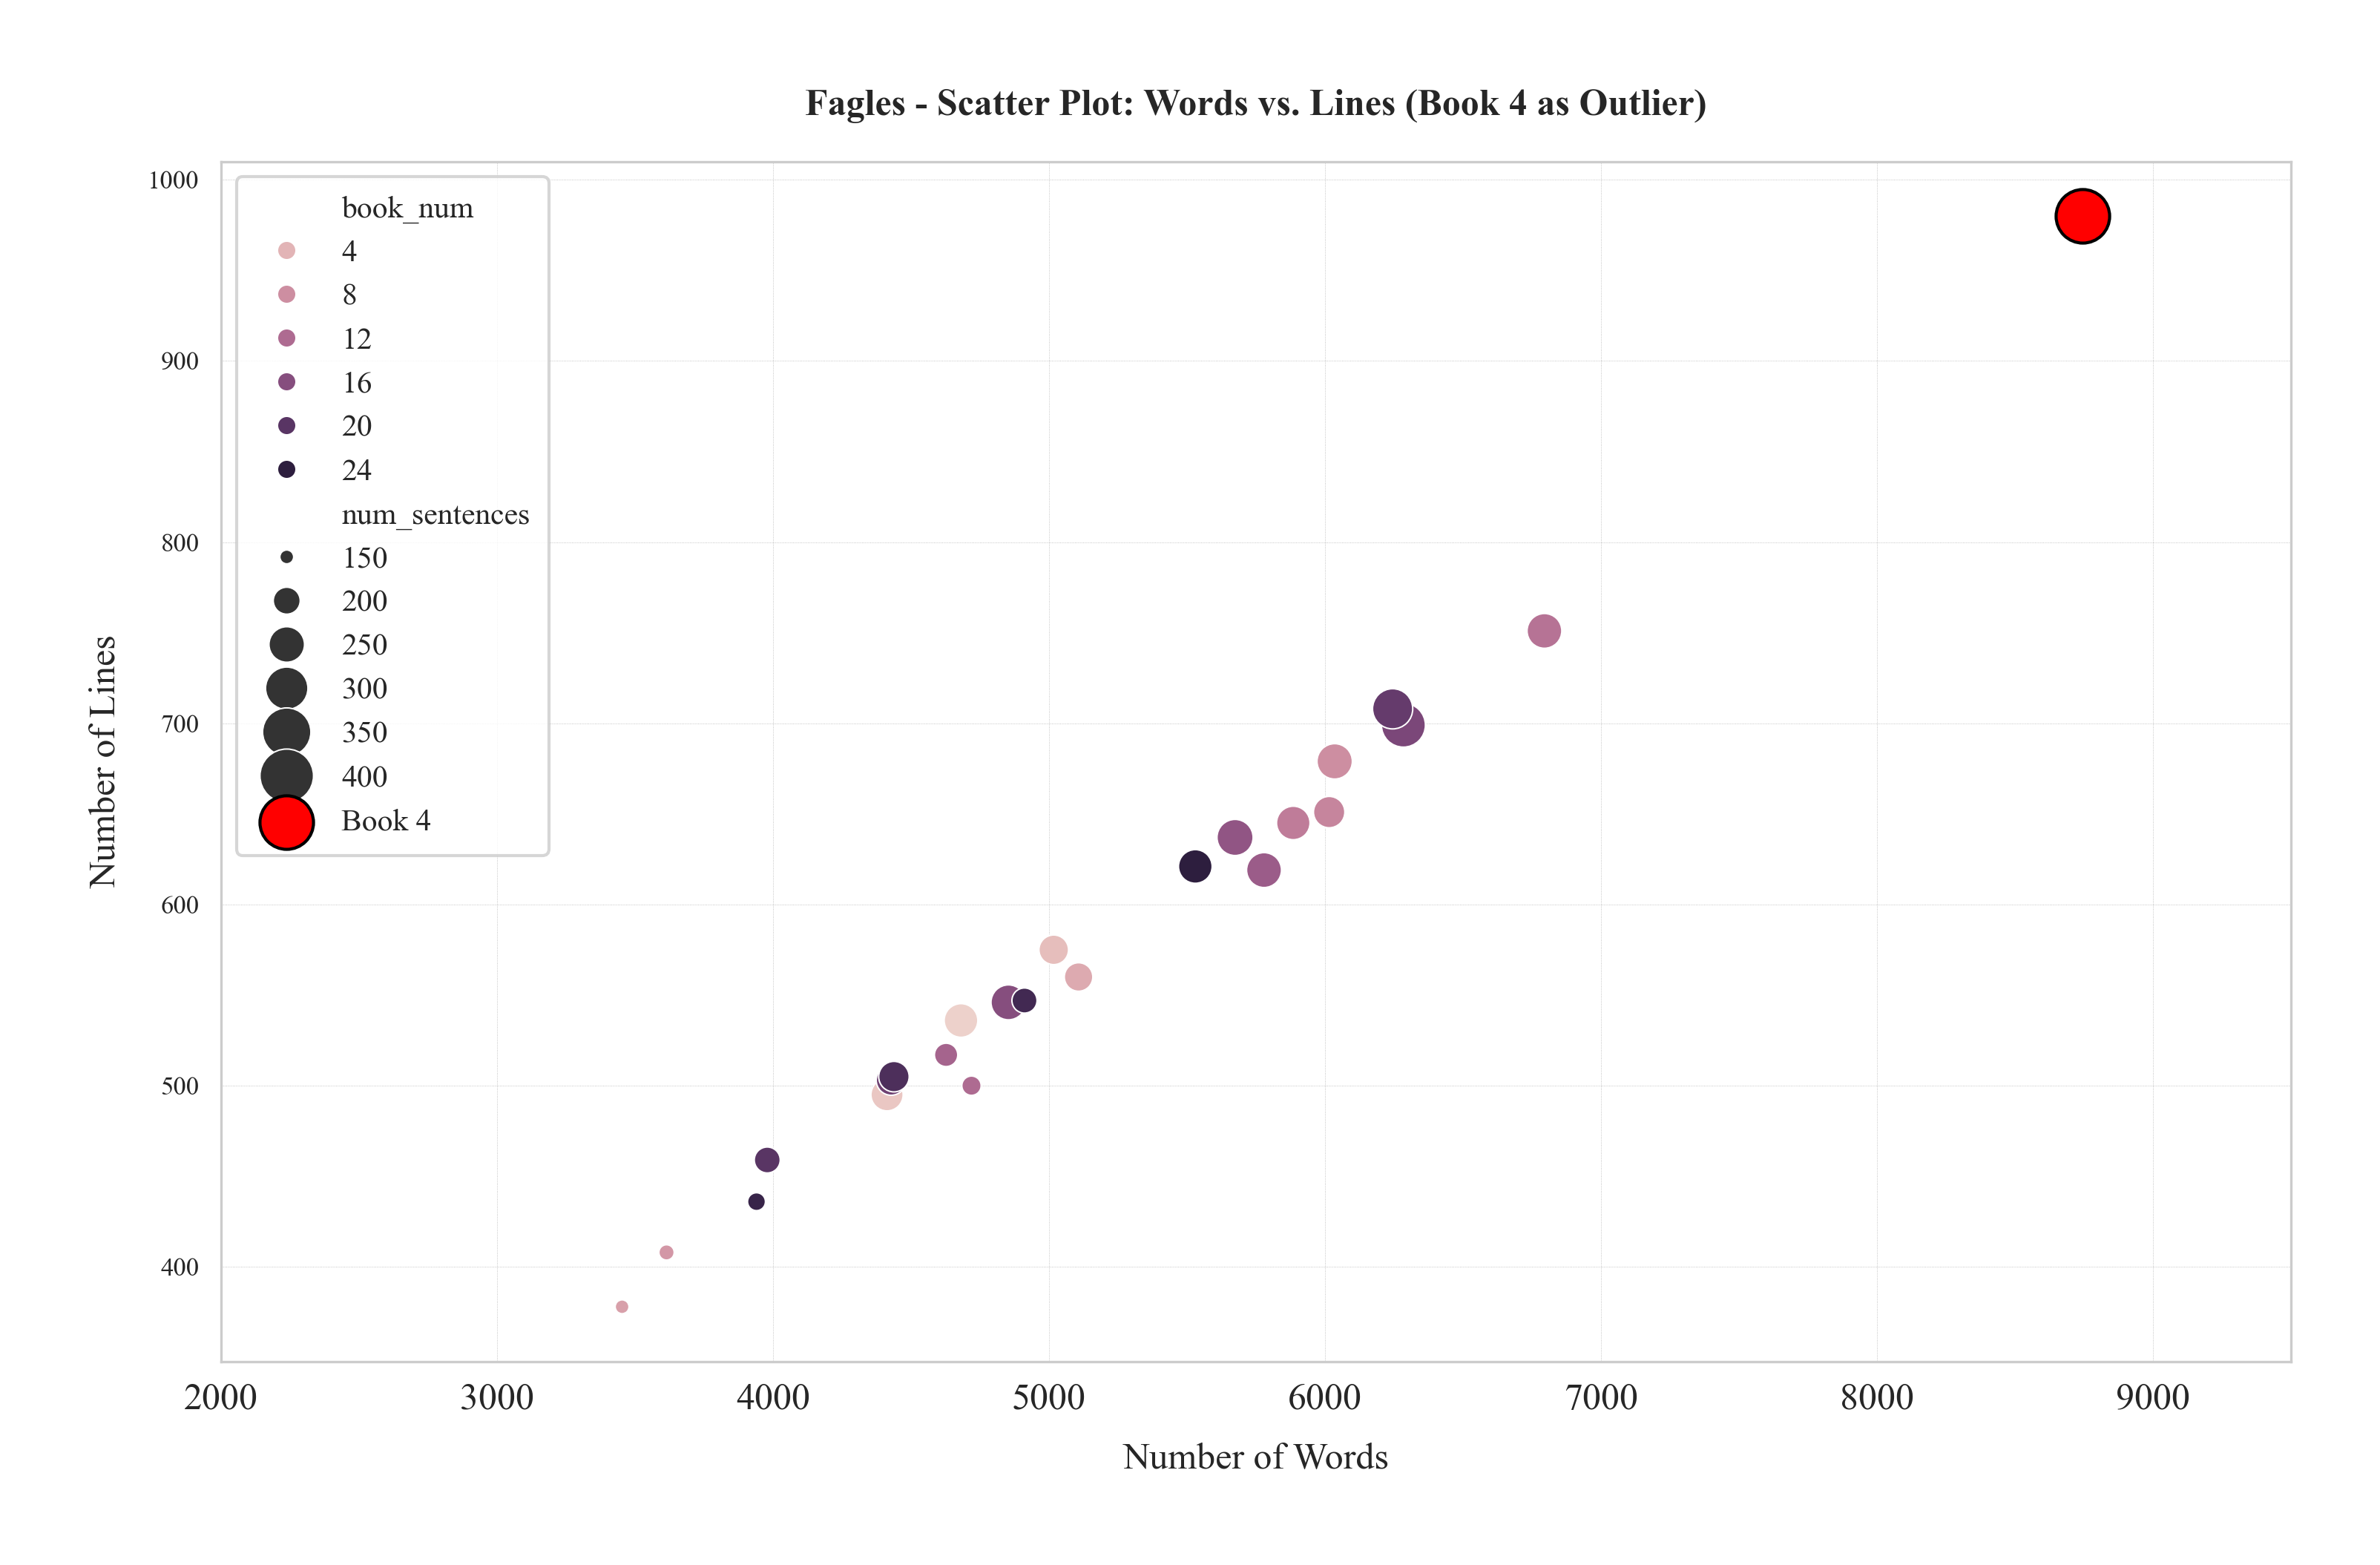

In [32]:
sns.scatterplot(data=df, x="num_words", y="num_lines", 
                hue="book_num", size="num_sentences", sizes=(20, 300))
# Highlight Book 4
plt.scatter(df[df["book_num"] == 4]["num_words"], 
            df[df["book_num"] == 4]["num_lines"], 
            color="red", s=300, label="Book 4", edgecolors="black")

plt.xlabel("Number of Words")
plt.ylabel("Number of Lines")
plt.title(f"{translator} - Scatter Plot: Words vs. Lines (Book 4 as Outlier)")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.xlim(2000, 9500) # same range as Wilson's plot
plt.savefig(f"{output_path_plots}/{translator}-Scatter_Words_Lines.png")
plt.show()

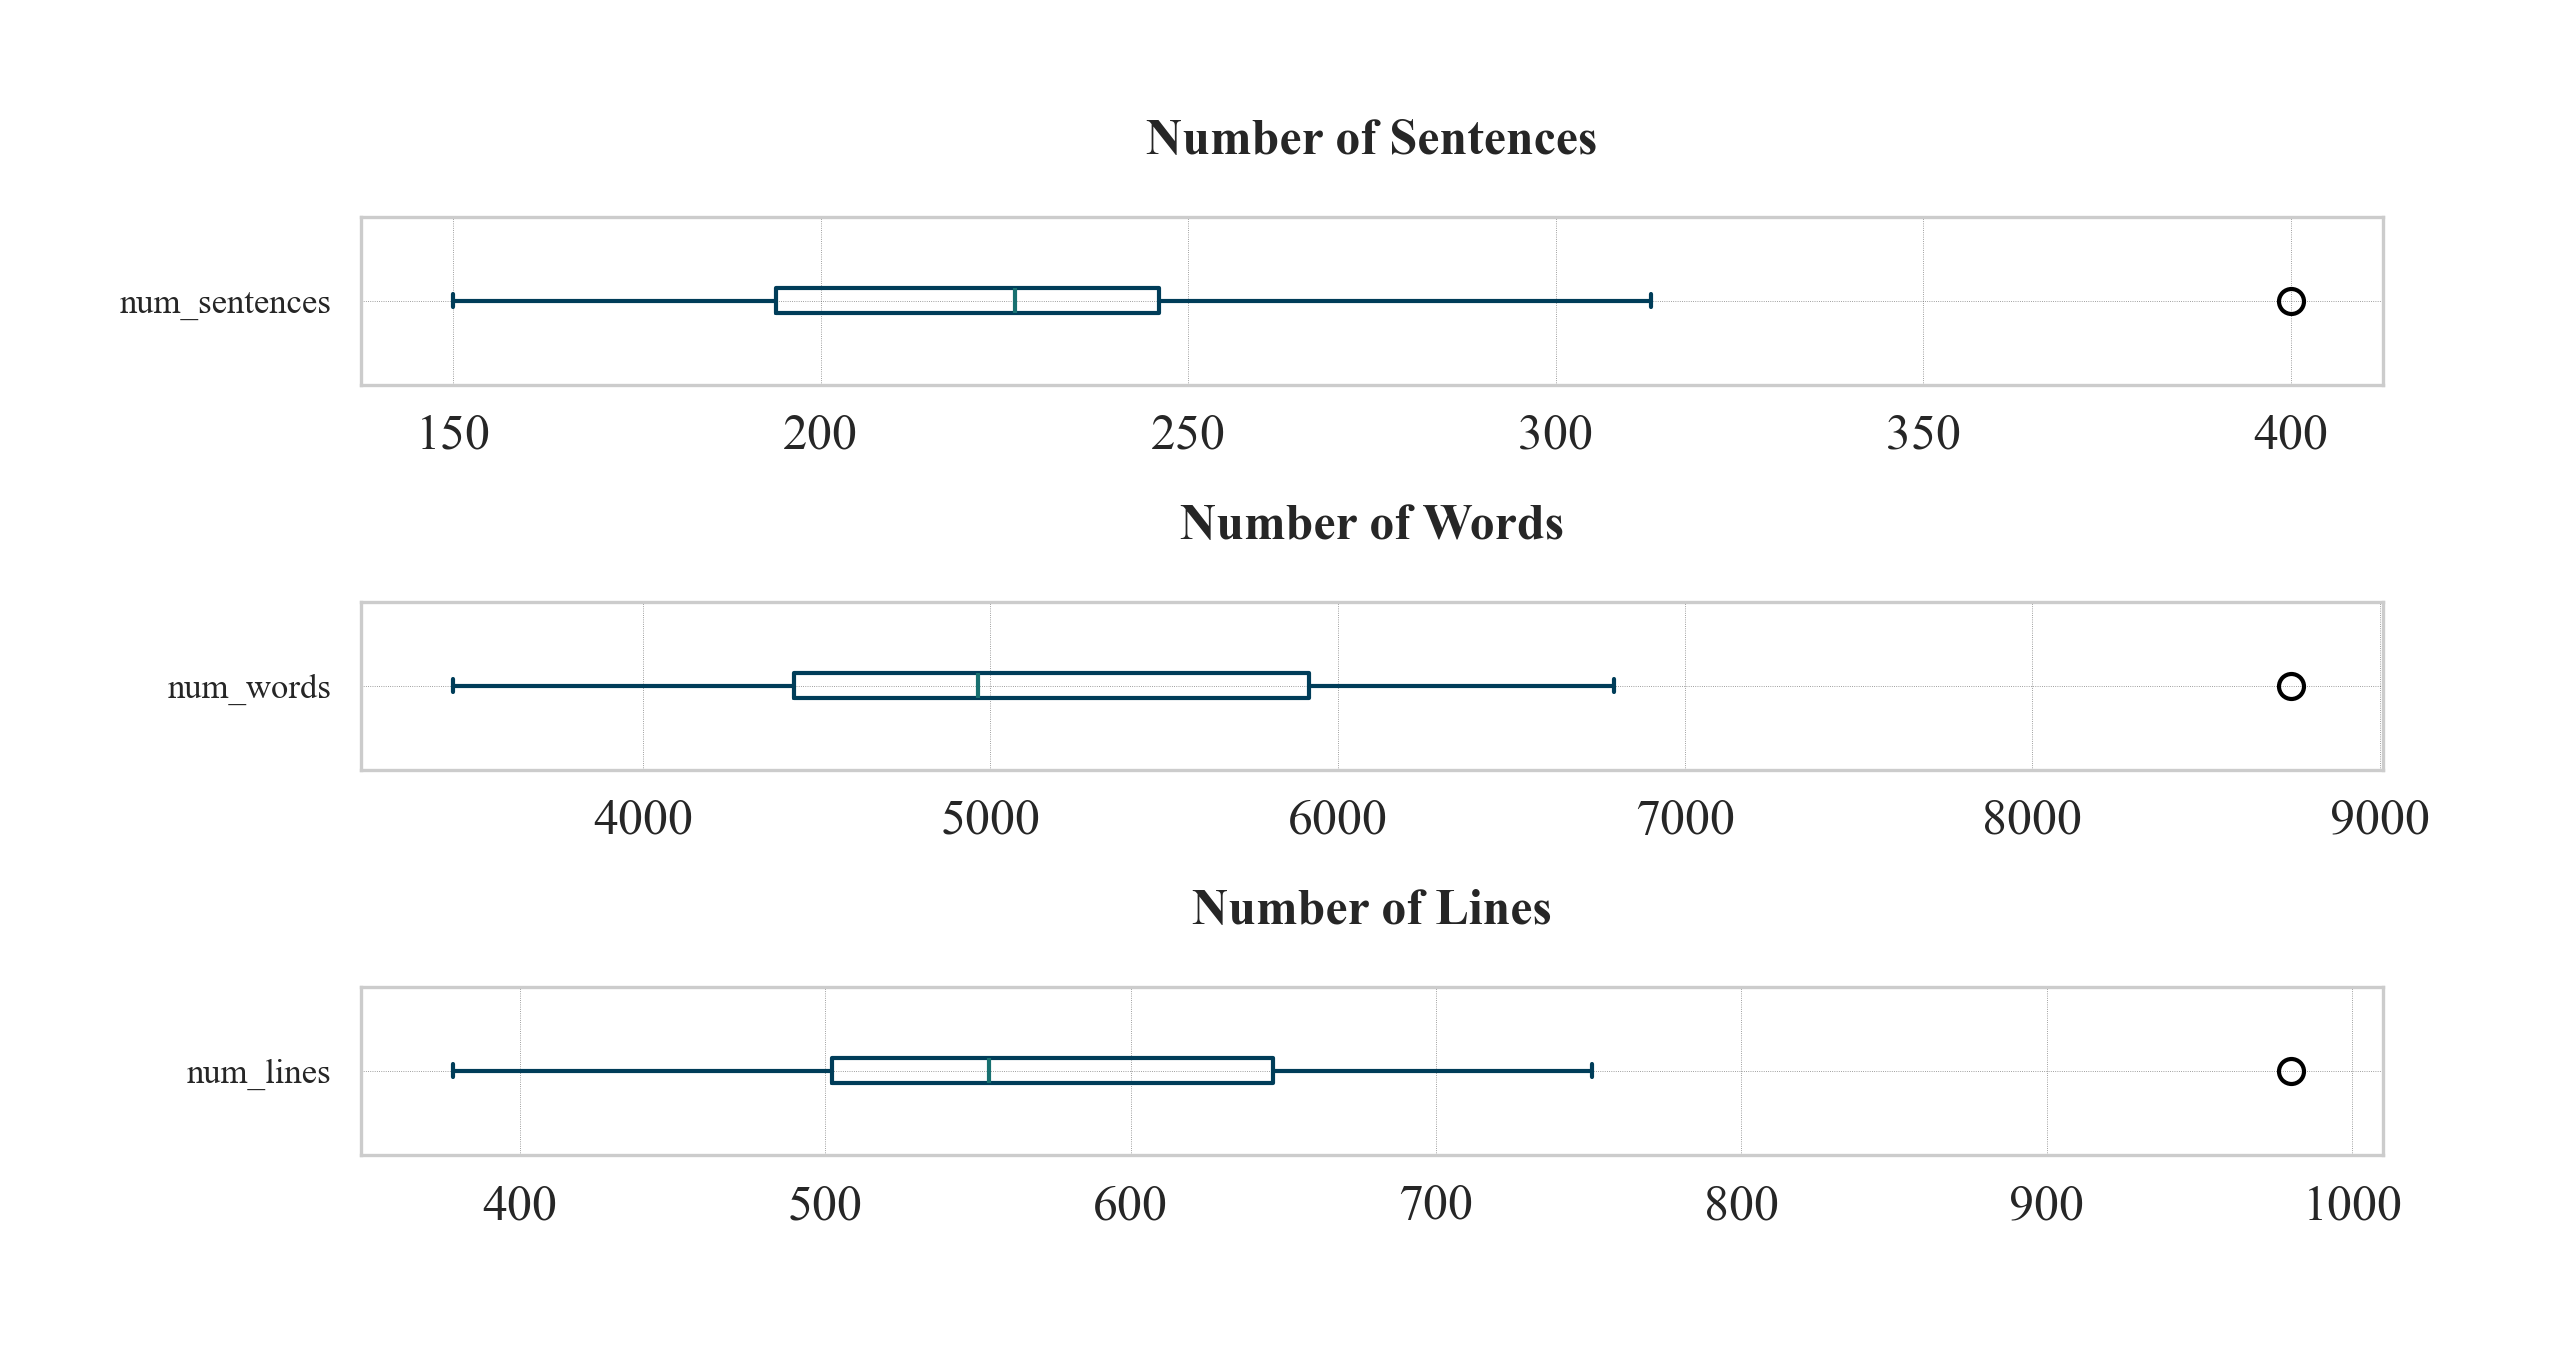

In [33]:
# Create a figure with 3 subplots (one for each variable)
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 4), sharex=False)

# Plot boxplots
df['num_sentences'].plot(kind='box', vert=False, ax=axes[0])
axes[0].set_title("Number of Sentences")
df['num_words'].plot(kind='box', vert=False, ax=axes[1])
axes[1].set_title("Number of Words")
df['num_lines'].plot(kind='box', vert=False, ax=axes[2])
axes[2].set_title("Number of Lines")
plt.tight_layout()
plt.savefig(f"{output_path_plots}/{translator}-Boxplots_Sentences_Words_Lines.png") 
plt.show()

## Custom and Customizable Tokenizer Pipeline

In [34]:
# NLTK Pipeline for Tokenizing Text
# Includes lowercasing, tokenization, and stopword removal
# Customizable stopwords with inclusions and exclusions

import string
from typing import List, Callable, Union, Set, Optional

# Download necessary NLTK resources
print("Downloading NLTK resources...")
nltk.download('punkt_tab')
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
print("Download complete.")

##############################################
# NLPPipeline Class
##############################################
class NLPPipeline:
    """
    A configurable NLP pipeline for linguistic text analysis.
    
    This class provides methods for text preprocessing, including:
    - Lowercasing
    - Tokenization using NLTK's word_tokenize
    - Punctuation removal with customizable punctuation sets
    - Stopword removal with customizable stopword lists
    """
    
    def __init__(self, language: str = 'english'):
        """
        Initialize the NLP pipeline.
        
        Args:
            language (str): Language for stopwords (default: 'english')
        """
        self.language = language
        self.stopwords = set(nltk.corpus.stopwords.words(language))
        self.custom_include_stopwords: Set[str] = set()
        self.custom_exclude_stopwords: Set[str] = set()
        self.update_stopwords()
        
        # Initialize punctuation set with string.punctuation
        self.default_punctuation = set(string.punctuation)
        self.keep_punctuation: Set[str] = set()
        self.punctuation_to_remove: Set[str] = set()
        self.update_punctuation()
    
    def update_stopwords(self) -> None:
        """
        Update the stopwords set based on custom inclusions and exclusions.
        """
        self.effective_stopwords = self.stopwords.copy()
        self.effective_stopwords |= self.custom_include_stopwords
        self.effective_stopwords -= self.custom_exclude_stopwords
    
    def update_punctuation(self) -> None:
        """
        Update the punctuation set based on custom inclusions and exclusions.
        """
        self.effective_punctuation = self.default_punctuation.copy()
        self.effective_punctuation -= self.keep_punctuation
        self.effective_punctuation |= self.punctuation_to_remove
    
    def customize_stopwords(self, include: Optional[Set[str]] = None, 
                           exclude: Optional[Set[str]] = None) -> None:
        """
        Customize the stopwords by including or excluding specific words.
        
        Args:
            include (Set[str], optional): Words to add to stopwords
            exclude (Set[str], optional): Words to remove from stopwords
        """
        if include:
            self.custom_include_stopwords |= include
        if exclude:
            self.custom_exclude_stopwords |= exclude
        self.update_stopwords()
        
        # Print summary of changes
        print(f"Stopwords customized:")
        if include:
            print(f"  Added: {include}")
        if exclude:
            print(f"  Removed: {exclude}")
        print(f"  Total stopwords: {len(self.effective_stopwords)}")
    
    def customize_punctuation(self, keep: Optional[Set[str]] = None,
                             remove: Optional[Set[str]] = None) -> None:
        """
        Customize the punctuation handling by specifying characters to keep or remove.
        
        Args:
            keep (Set[str], optional): Punctuation characters to keep
            remove (Set[str], optional): Additional characters to remove
        """
        if keep:
            self.keep_punctuation |= keep
        if remove:
            self.punctuation_to_remove |= remove
        self.update_punctuation()
        
        # Print summary of changes
        print(f"Punctuation customized:")
        if keep:
            print(f"  Keeping: {keep}")
        if remove:
            print(f"  Additional removals: {remove}")
        print(f"  Punctuation to be removed: {''.join(sorted(self.effective_punctuation))}")
    
    def lowercase(self, text: str) -> str:
        """
        Convert text to lowercase.
        
        Args:
            text (str): Input text
            
        Returns:
            str: Lowercase text
        """
        if not isinstance(text, str):
            return ""
        return text.lower()
    
    def tokenize(self, text: str) -> List[str]:
        """
        Tokenize text using NLTK's word_tokenize.
        
        Args:
            text (str): Input text
            
        Returns:
            List[str]: List of tokens
        """
        if not isinstance(text, str):
            return []
        text = text.replace("—", " ").replace("–", " ")
        return nltk.tokenize.word_tokenize(text)
    
    def remove_punctuation(self, tokens: List[str]) -> List[str]:
        """
        Remove punctuation from tokens or filter out punctuation-only tokens.
        
        Args:
            tokens (List[str]): List of tokens
            
        Returns:
            List[str]: Tokens with punctuation removed
        """
        # Create a translation table for punctuation removal
        punct_table = str.maketrans('', '', ''.join(self.effective_punctuation))
        
        # Apply translation to each token and filter out empty tokens
        cleaned_tokens = []
        for token in tokens:
            cleaned = token.translate(punct_table)
            if cleaned:  # Only add non-empty tokens
                cleaned_tokens.append(cleaned)
        
        return cleaned_tokens
    
    def remove_stopwords(self, tokens: List[str]) -> List[str]:
        """
        Remove stopwords from the list of tokens.
        
        Args:
            tokens (List[str]): List of tokens
            
        Returns:
            List[str]: Filtered list without stopwords
        """
        return [t for t in tokens if t.lower() not in self.effective_stopwords]
    
    def get_pipeline(self, lowercase: bool = True, 
                    tokenize: bool = True,
                    remove_punctuation: bool = True,
                    remove_stops: bool = True) -> List[Callable]:
        """
        Get a customized processing pipeline.
        
        Args:
            lowercase (bool): Include lowercasing step
            tokenize (bool): Include tokenization step
            remove_punctuation (bool): Include punctuation removal step
            remove_stops (bool): Include stopword removal step
            
        Returns:
            List[Callable]: List of processing functions
        """
        pipeline = []
        if lowercase:
            pipeline.append(self.lowercase)
        if tokenize:
            pipeline.append(self.tokenize)
        if remove_punctuation:
            pipeline.append(self.remove_punctuation)
        if remove_stops:
            pipeline.append(self.remove_stopwords)
        return pipeline
    
    def process_text(self, text: str, pipeline: Optional[List[Callable]] = None) -> Union[str, List[str]]:
        """
        Process a single text through the pipeline.
        
        Args:
            text (str): Text to process
            pipeline (List[Callable], optional): Custom pipeline to use
            
        Returns:
            Union[str, List[str]]: Processed text or tokens
        """
        if pipeline is None:
            pipeline = self.get_pipeline()
        
        result = text
        for transform in pipeline:
            try:
                result = transform(result)
            except Exception as e:
                print(f"Error applying {transform.__name__}: {e}")
        return result
    
    def process_series(self, series: pd.Series, pipeline: Optional[List[Callable]] = None) -> pd.Series:
        """
        Process a pandas Series of texts through the pipeline with progress bar.
        
        Args:
            series (pd.Series): Series containing texts
            pipeline (List[Callable], optional): Custom pipeline to use
            
        Returns:
            pd.Series: Series with processed texts/tokens
        """
        if pipeline is None:
            pipeline = self.get_pipeline()
        
        tqdm.pandas(desc="Processing texts")
        return series.progress_apply(lambda x: self.process_text(x, pipeline))
    
    def process_dataframe(self, df: pd.DataFrame, text_column: str, 
                         result_column: str, pipeline: Optional[List[Callable]] = None) -> pd.DataFrame:
        """
        Process a dataframe by applying the pipeline to a text column.
        
        Args:
            df (pd.DataFrame): Input dataframe
            text_column (str): Column containing texts to process
            result_column (str): Column name for storing processed results
            pipeline (List[Callable], optional): Custom pipeline to use
            
        Returns:
            pd.DataFrame: Processed dataframe
        """
        if text_column not in df.columns:
            raise ValueError(f"Column '{text_column}' not found in dataframe")
        
        result_df = df.copy()
        result_df[result_column] = self.process_series(df[text_column], pipeline)
        return result_df
##################################################
# End of NLPPipeline Class
##################################################
# Initialize the pipeline
nlp = NLPPipeline(language='english')

# Customize stopwords
nlp.customize_stopwords(
    include={'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'ten'},
    exclude={''}
)
# Customize punctuation
nlp.customize_punctuation(
    keep={'-', "'"},  # Keep hyphens and apostrophes
    remove={'…', '—','”','’','“', '‘'}  # Additional characters to remove
)

# Process with default pipeline (lowercase -> tokenize -> remove punctuation -> remove stopwords)
df = nlp.process_dataframe(df, 'text', 'tokens')

Download complete.
Stopwords customized:
  Added: {'four', 'ten', 'five', 'one', 'three', 'seven', 'eight', 'six', 'two', 'nine'}
  Removed: {''}
  Total stopwords: 208
Punctuation customized:
  Keeping: {"'", '-'}
  Additional removals: {'”', '‘', '…', '“', '’', '—'}
  Punctuation to be removed: !"#$%&()*+,./:;<=>?@[\]^_`{|}~—‘’“”…


[nltk_data] Downloading package punkt_tab to /Users/debr/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Processing texts:   0%|          | 0/24 [00:00<?, ?it/s]

In [35]:
df['num_tokens'] = df['tokens'].map(len)

## Most Frequent and Keywords

In [39]:
from collections import Counter
counter = Counter()
df['tokens'].map(counter.update)
keywords = [word for word, count in counter.most_common(10)]
keywords_count = counter.most_common(10)
print(keywords)
print(keywords_count)

['odysseus', 'man', 'home', 'back', 'son', 'men', 'house', 'come', 'never', 'gods']
[('odysseus', 560), ('man', 559), ('home', 404), ('back', 364), ('son', 351), ('men', 346), ('house', 308), ('come', 288), ('never', 271), ('gods', 267)]


Those most frequent tokens are exactly what one would expect from an Odyssey translation. What it is impressive, more if we consider modern interpretations (since 1500), the omission of mother and Penelope in the first 30 most frequent words. 

In [59]:
from collections import Counter ###
def count_words(df, column='tokens', preprocess=None, min_freq=2):

    # process tokens and update counter
    def update(doc):
        tokens = doc if preprocess is None else preprocess(doc)
        counter.update(tokens)

    # create counter and run through all data
    counter = Counter()
    df[column].progress_map(update)

    # transform counter into data frame
    freq_df = pd.DataFrame.from_dict(counter, orient='index', columns=['freq'])
    freq_df = freq_df.query('freq >= @min_freq')
    freq_df.index.name = 'token'

    return freq_df.sort_values('freq', ascending=False)
freq_df = count_words(df)
freq_df.head(50)

Processing texts:   0%|          | 0/24 [00:00<?, ?it/s]

,freq
token,
odysseus,560
man,559
home,404
back,364
son,351
men,346
house,308
come,288
never,271


In [42]:
# finding a token in token column
token = 'penelope'
penelopes = df['tokens'].map(lambda tokens: token in tokens).sum()
penelopes

np.int64(17)

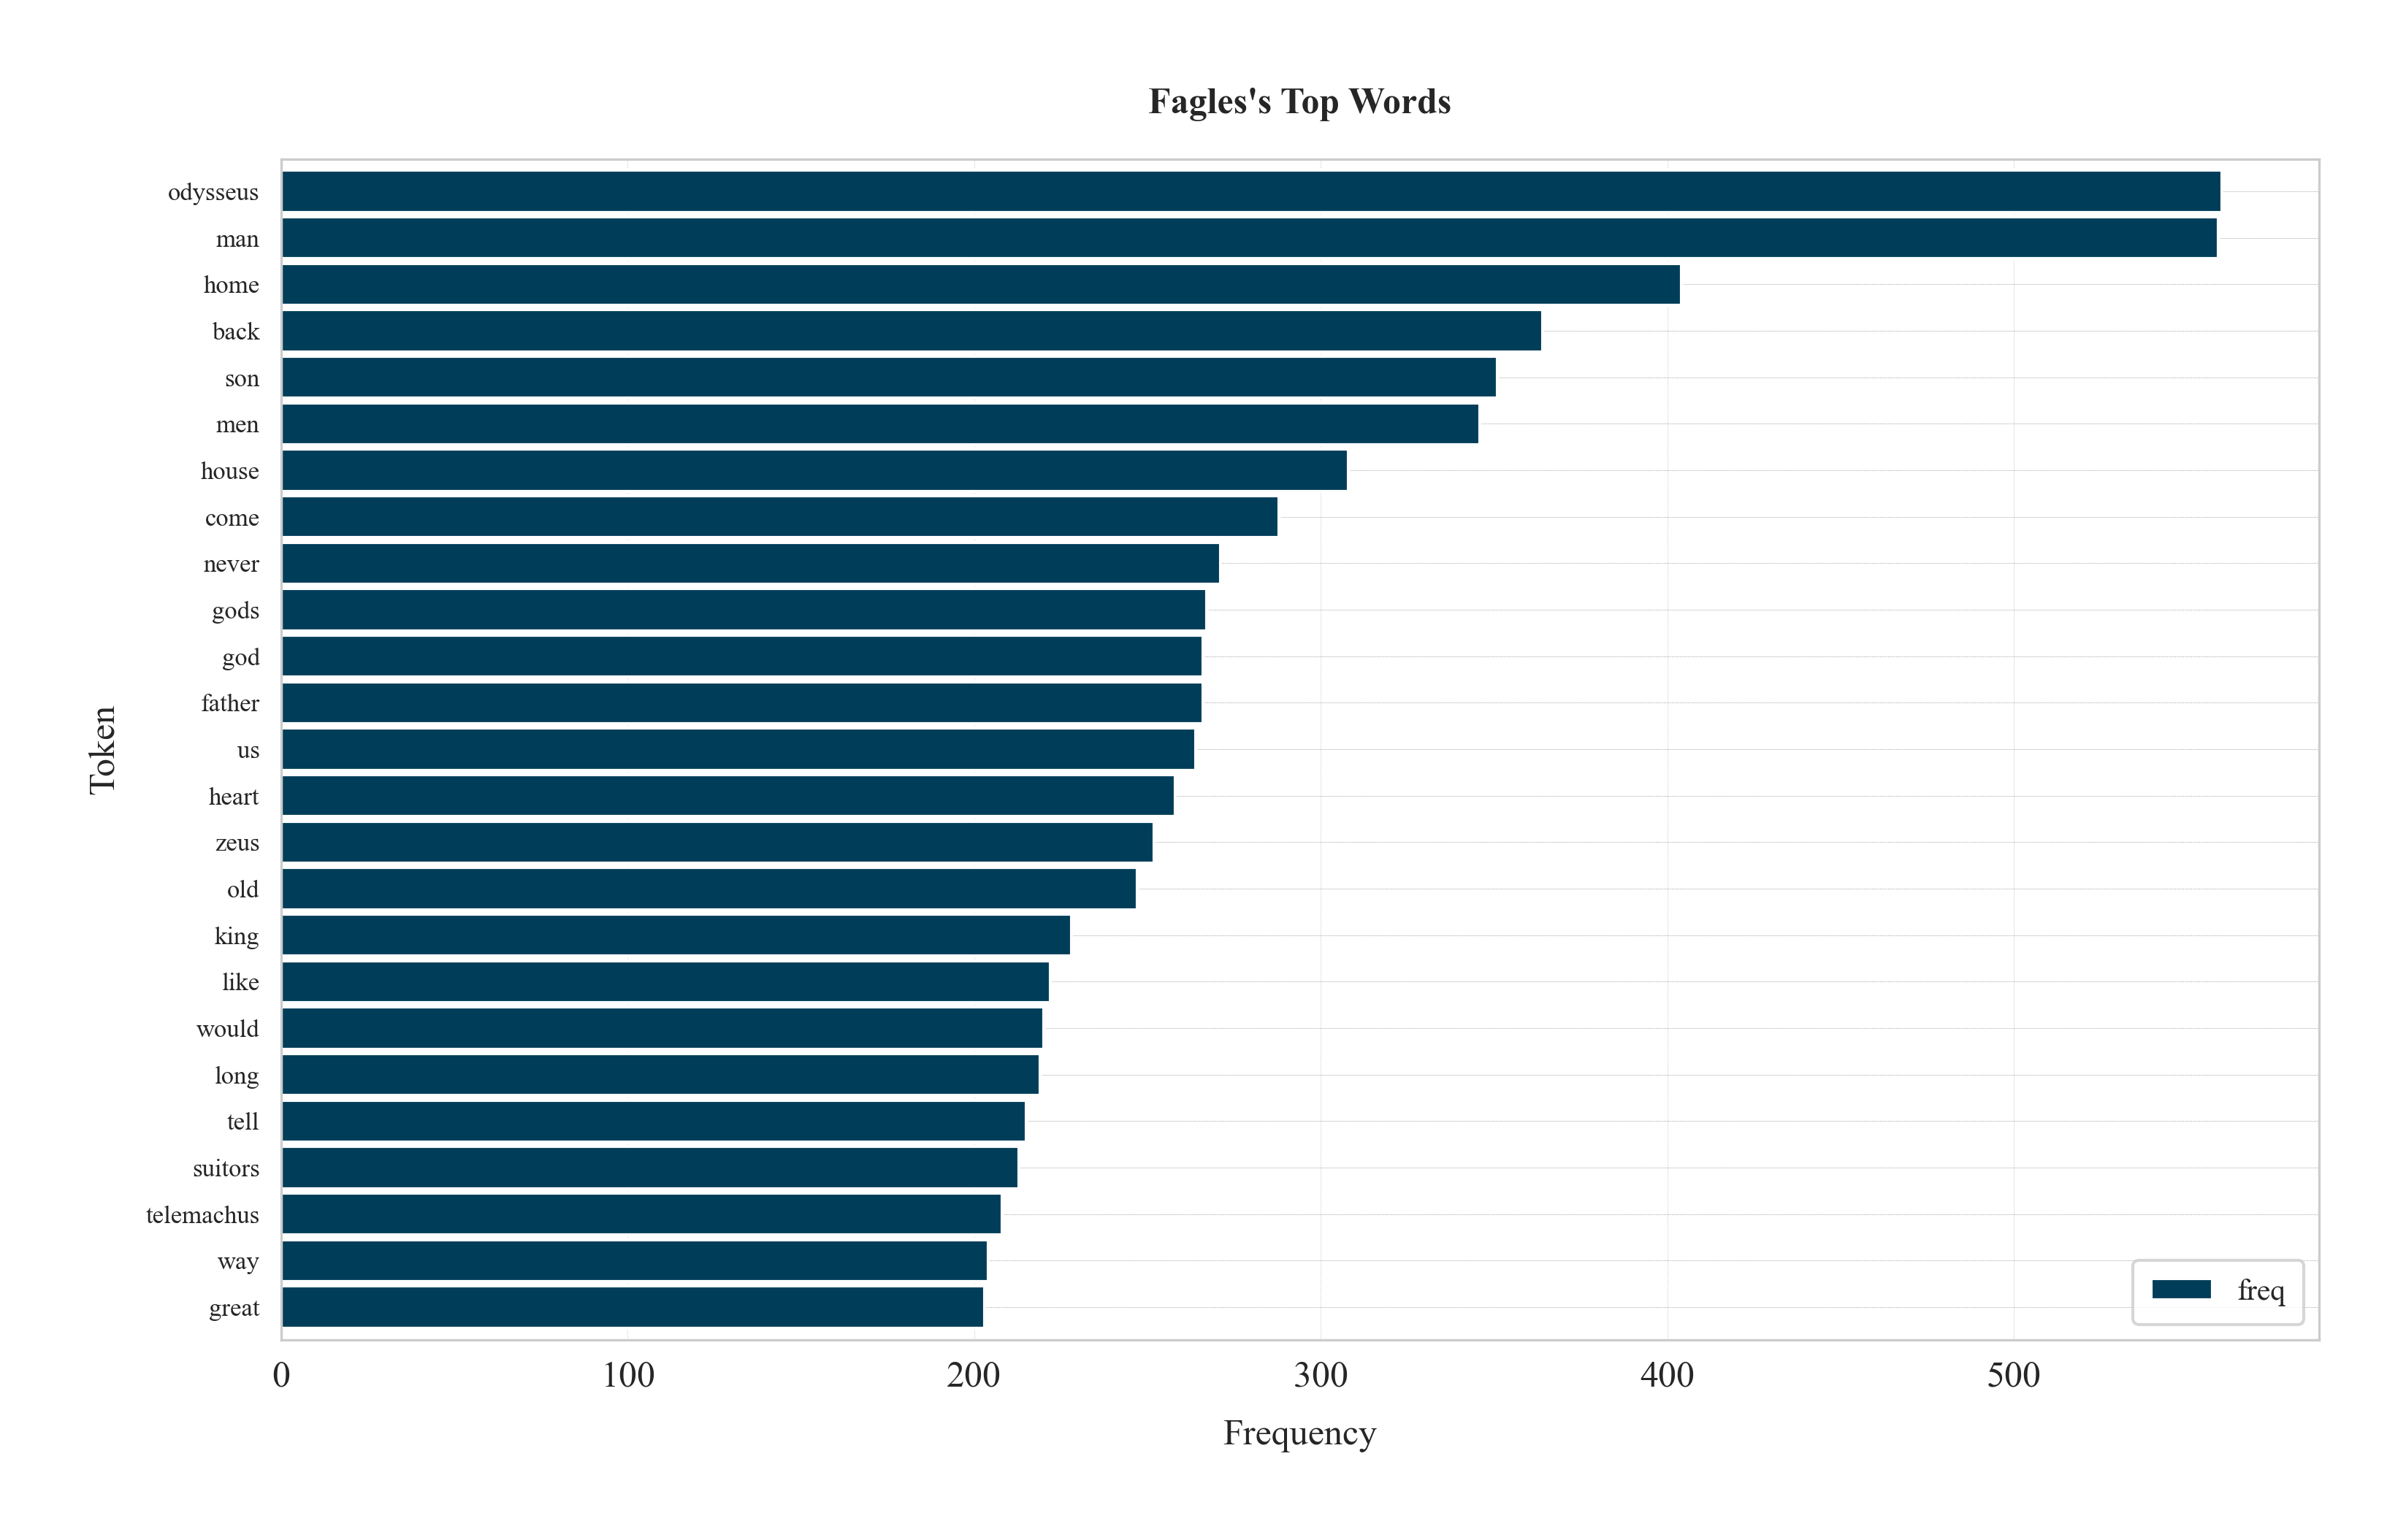

In [41]:
ax = freq_df.head(25).plot(kind='barh', width=0.9)
ax.invert_yaxis()
ax.set(xlabel='Frequency', ylabel='Token', title=f"{translator}'s Top Words")
plt.grid(axis='x', alpha=0.3)
plt.savefig(f"/Users/debr/English-Homer/EDA_by_Author/{translator}_EDA/plots/{translator}-Top_Words.png")
plt.show()

### Wordcloud of Most Frequent

In [ ]:
from wordcloud import WordCloud
from matplotlib import pyplot as plt

text = df.query("book_num==1")['text'].values[0]
stopwords = set(nltk.corpus.stopwords.words('english'))
plt.figure(figsize=(12, 7)) ###
wc = WordCloud(max_words=100, stopwords=stopwords)
wc.generate(text)
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")

In [ ]:
text = df.query("book_num==20")['text'].values[0]
stopwords = set(nltk.corpus.stopwords.words('english'))
plt.figure(figsize=(12, 7)) ###
wc = WordCloud(max_words=100, stopwords=stopwords)
wc.generate(text)
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")

In [ ]:
from wordcloud import WordCloud ###
from collections import Counter ###

def wordcloud(word_freq, title=None, max_words=200, stopwords=None):

    wc = WordCloud(width=800, height=400,
                   background_color= 'white', colormap="Paired",
                   max_font_size=150, max_words=max_words)

    # convert data frame into dict
    if type(word_freq) == pd.Series:
        counter = Counter(word_freq.fillna(0).to_dict())
    else:
        counter = word_freq

    # filter stop words in frequency counter
    if stopwords is not None:
        counter = {token:freq for (token, freq) in counter.items()
                              if token not in stopwords}
    wc.generate_from_frequencies(counter)

    plt.title(title)

    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")

freq_df = count_words(df[df['book_num']==8])
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)###
wordcloud(freq_df['freq'], max_words=100)
plt.subplot(1,2,2)###
wordcloud(freq_df['freq'], max_words=100, stopwords=freq_df.head(50).index)
plt.tight_layout()###

### Keywords to DataFrame

In [49]:
def count_keywords(tokens, keywords):
    tokens = [t for t in tokens if t in keywords]
    counter = Counter(tokens)
    return [counter.get(k, 0) for k in keywords]
def count_keywords_by(df, by, keywords, column='tokens'):

    df = df.reset_index(drop=True) # if the supplied dataframe has gaps in the index
    freq_matrix = df[column].progress_apply(count_keywords, keywords=keywords)
    freq_df = pd.DataFrame.from_records(freq_matrix, columns=keywords)
    freq_df[by] = df[by] # copy the grouping column(s)

    return freq_df.groupby(by=by).sum().sort_values(by)

freq_df = count_keywords_by(df, 'book_num', keywords)
freq_df.head(2)

Processing texts:   0%|          | 0/24 [00:00<?, ?it/s]

,odysseus,man,home,back,son,men,house,come,never,gods
book_num,,,,,,,,,,
1,23,25,22,11,19,14,19,18,6,19
2,21,20,14,13,11,13,15,14,9,6


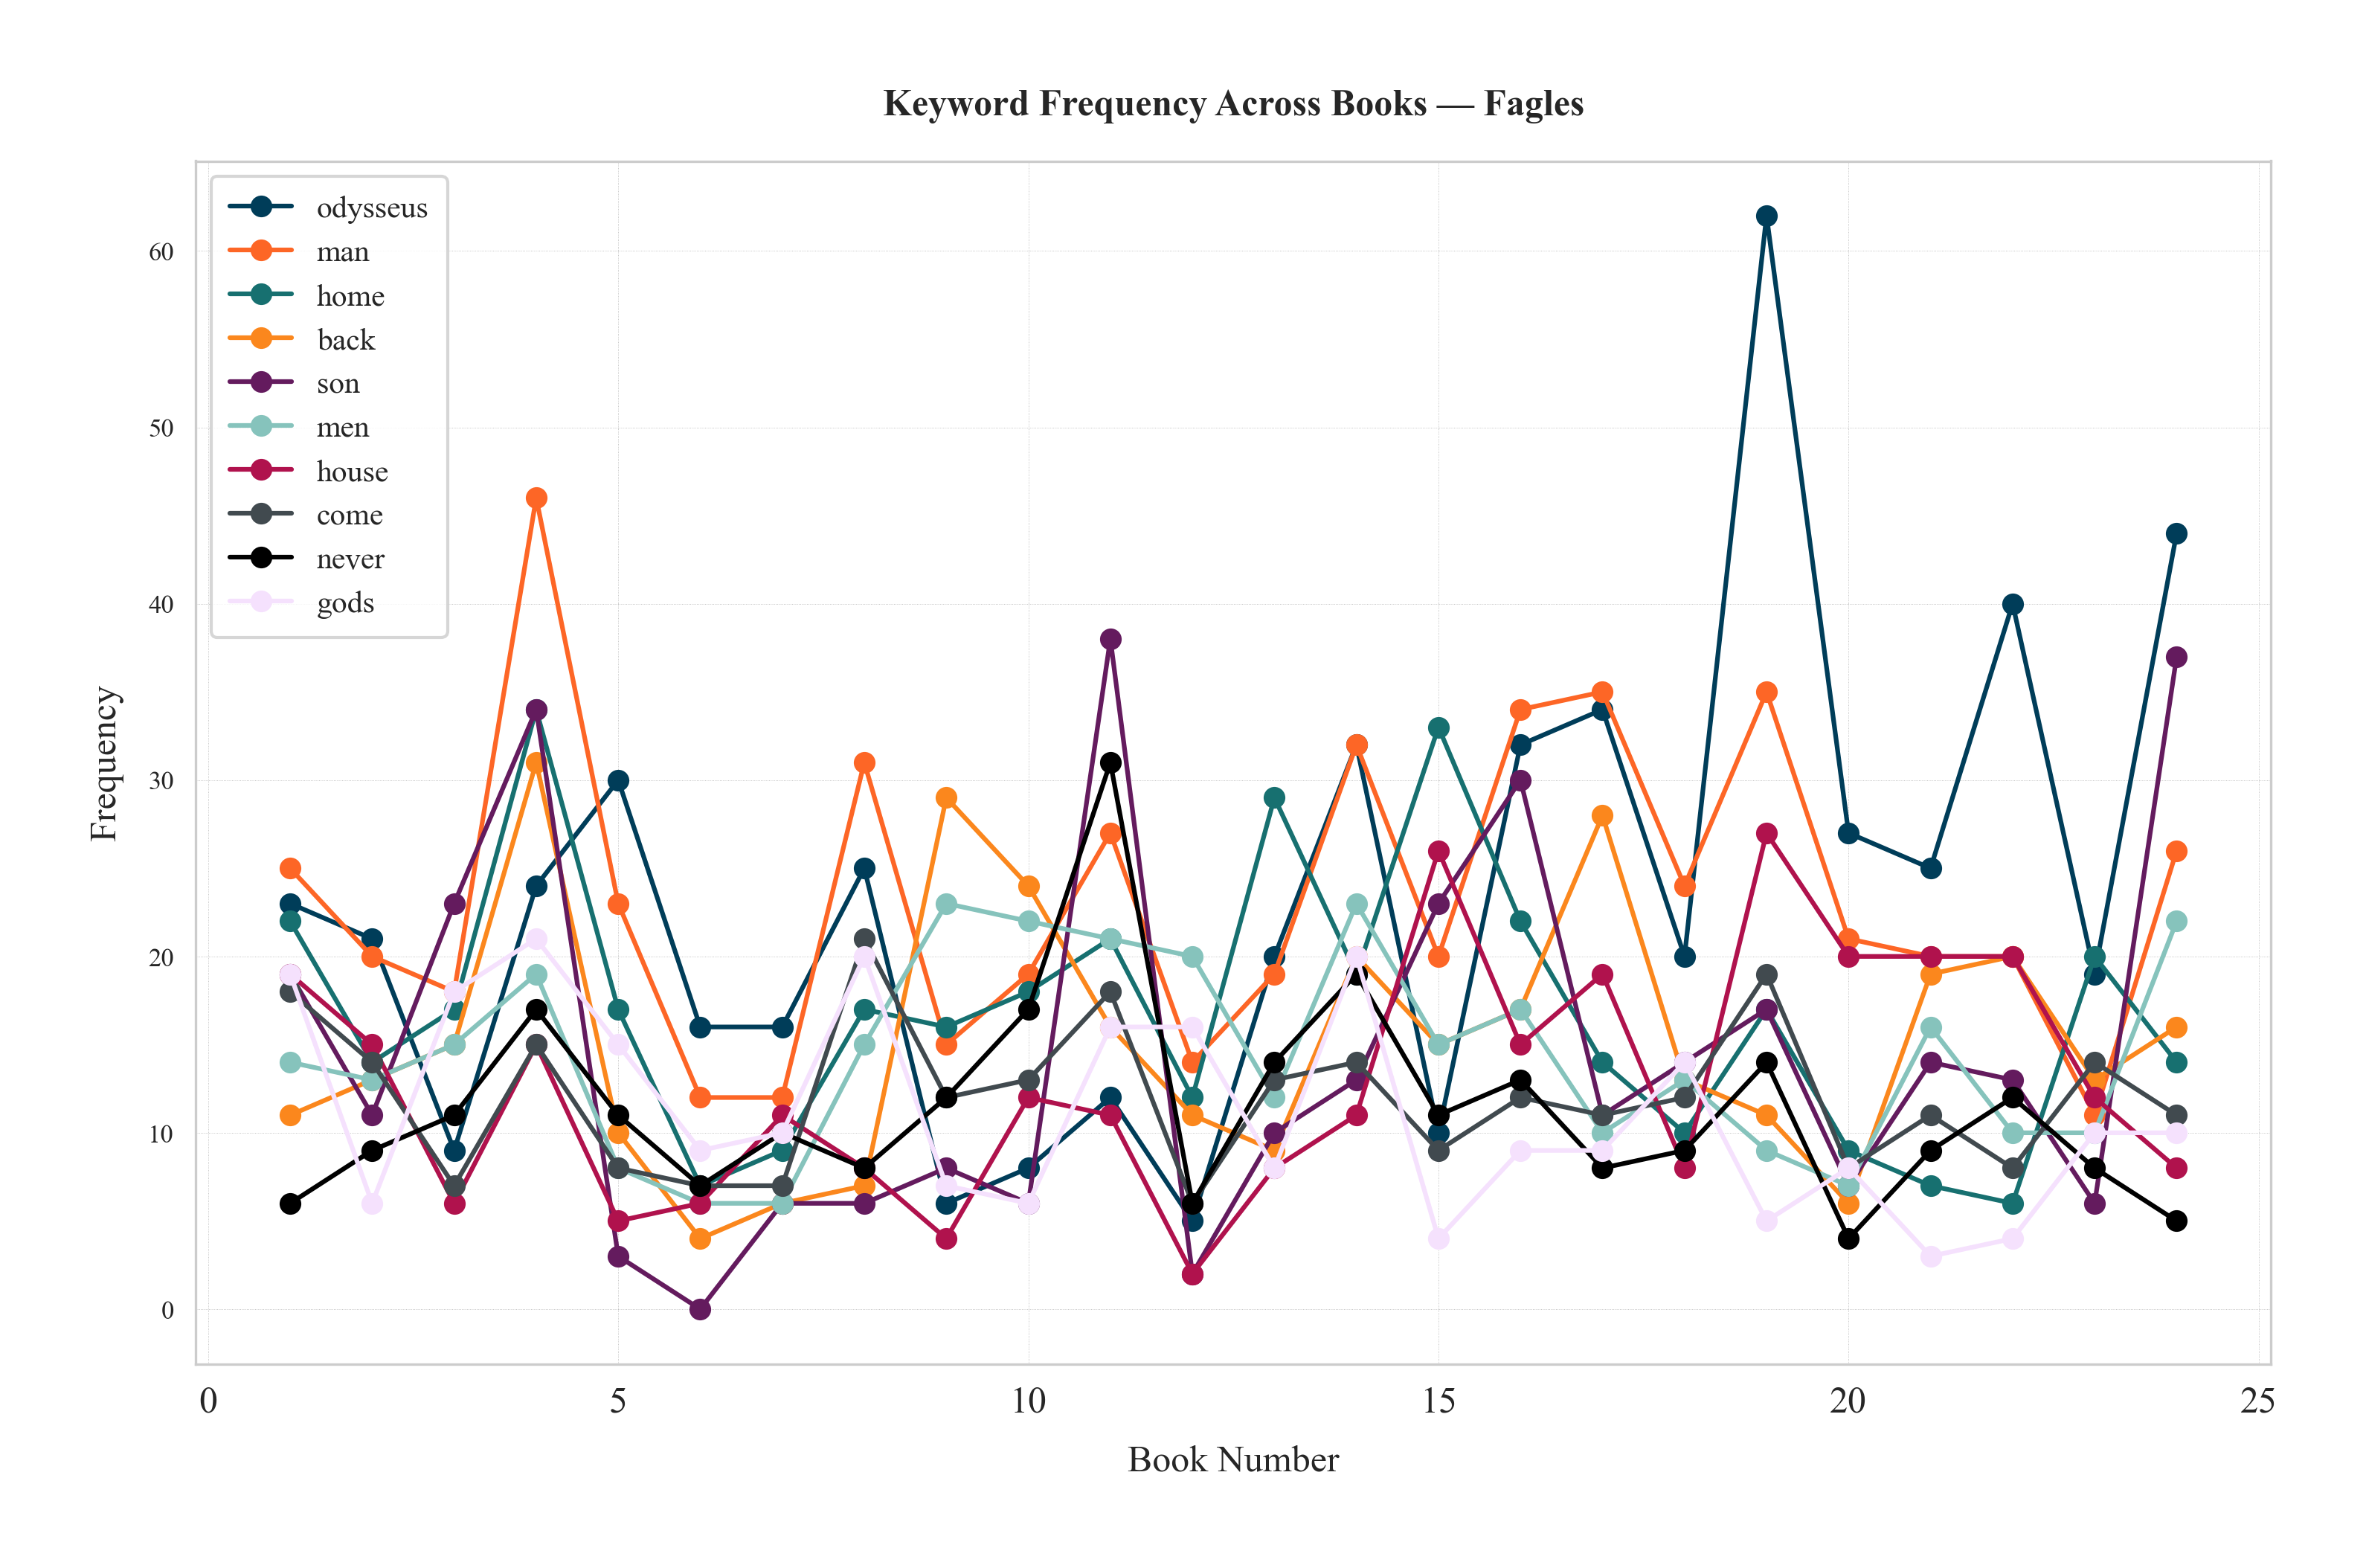

In [50]:
freq_df.plot(kind='line', figsize=(12, 7), marker='o')
plt.title(f'Keyword Frequency Across Books — {translator}')
plt.xlabel('Book Number')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.savefig(f"/Users/debr/English-Homer/EDA_by_Author/{translator}_EDA/plots/{translator}-Keyword_Frequency.png")
plt.show()

Processing texts:   0%|          | 0/24 [00:00<?, ?it/s]

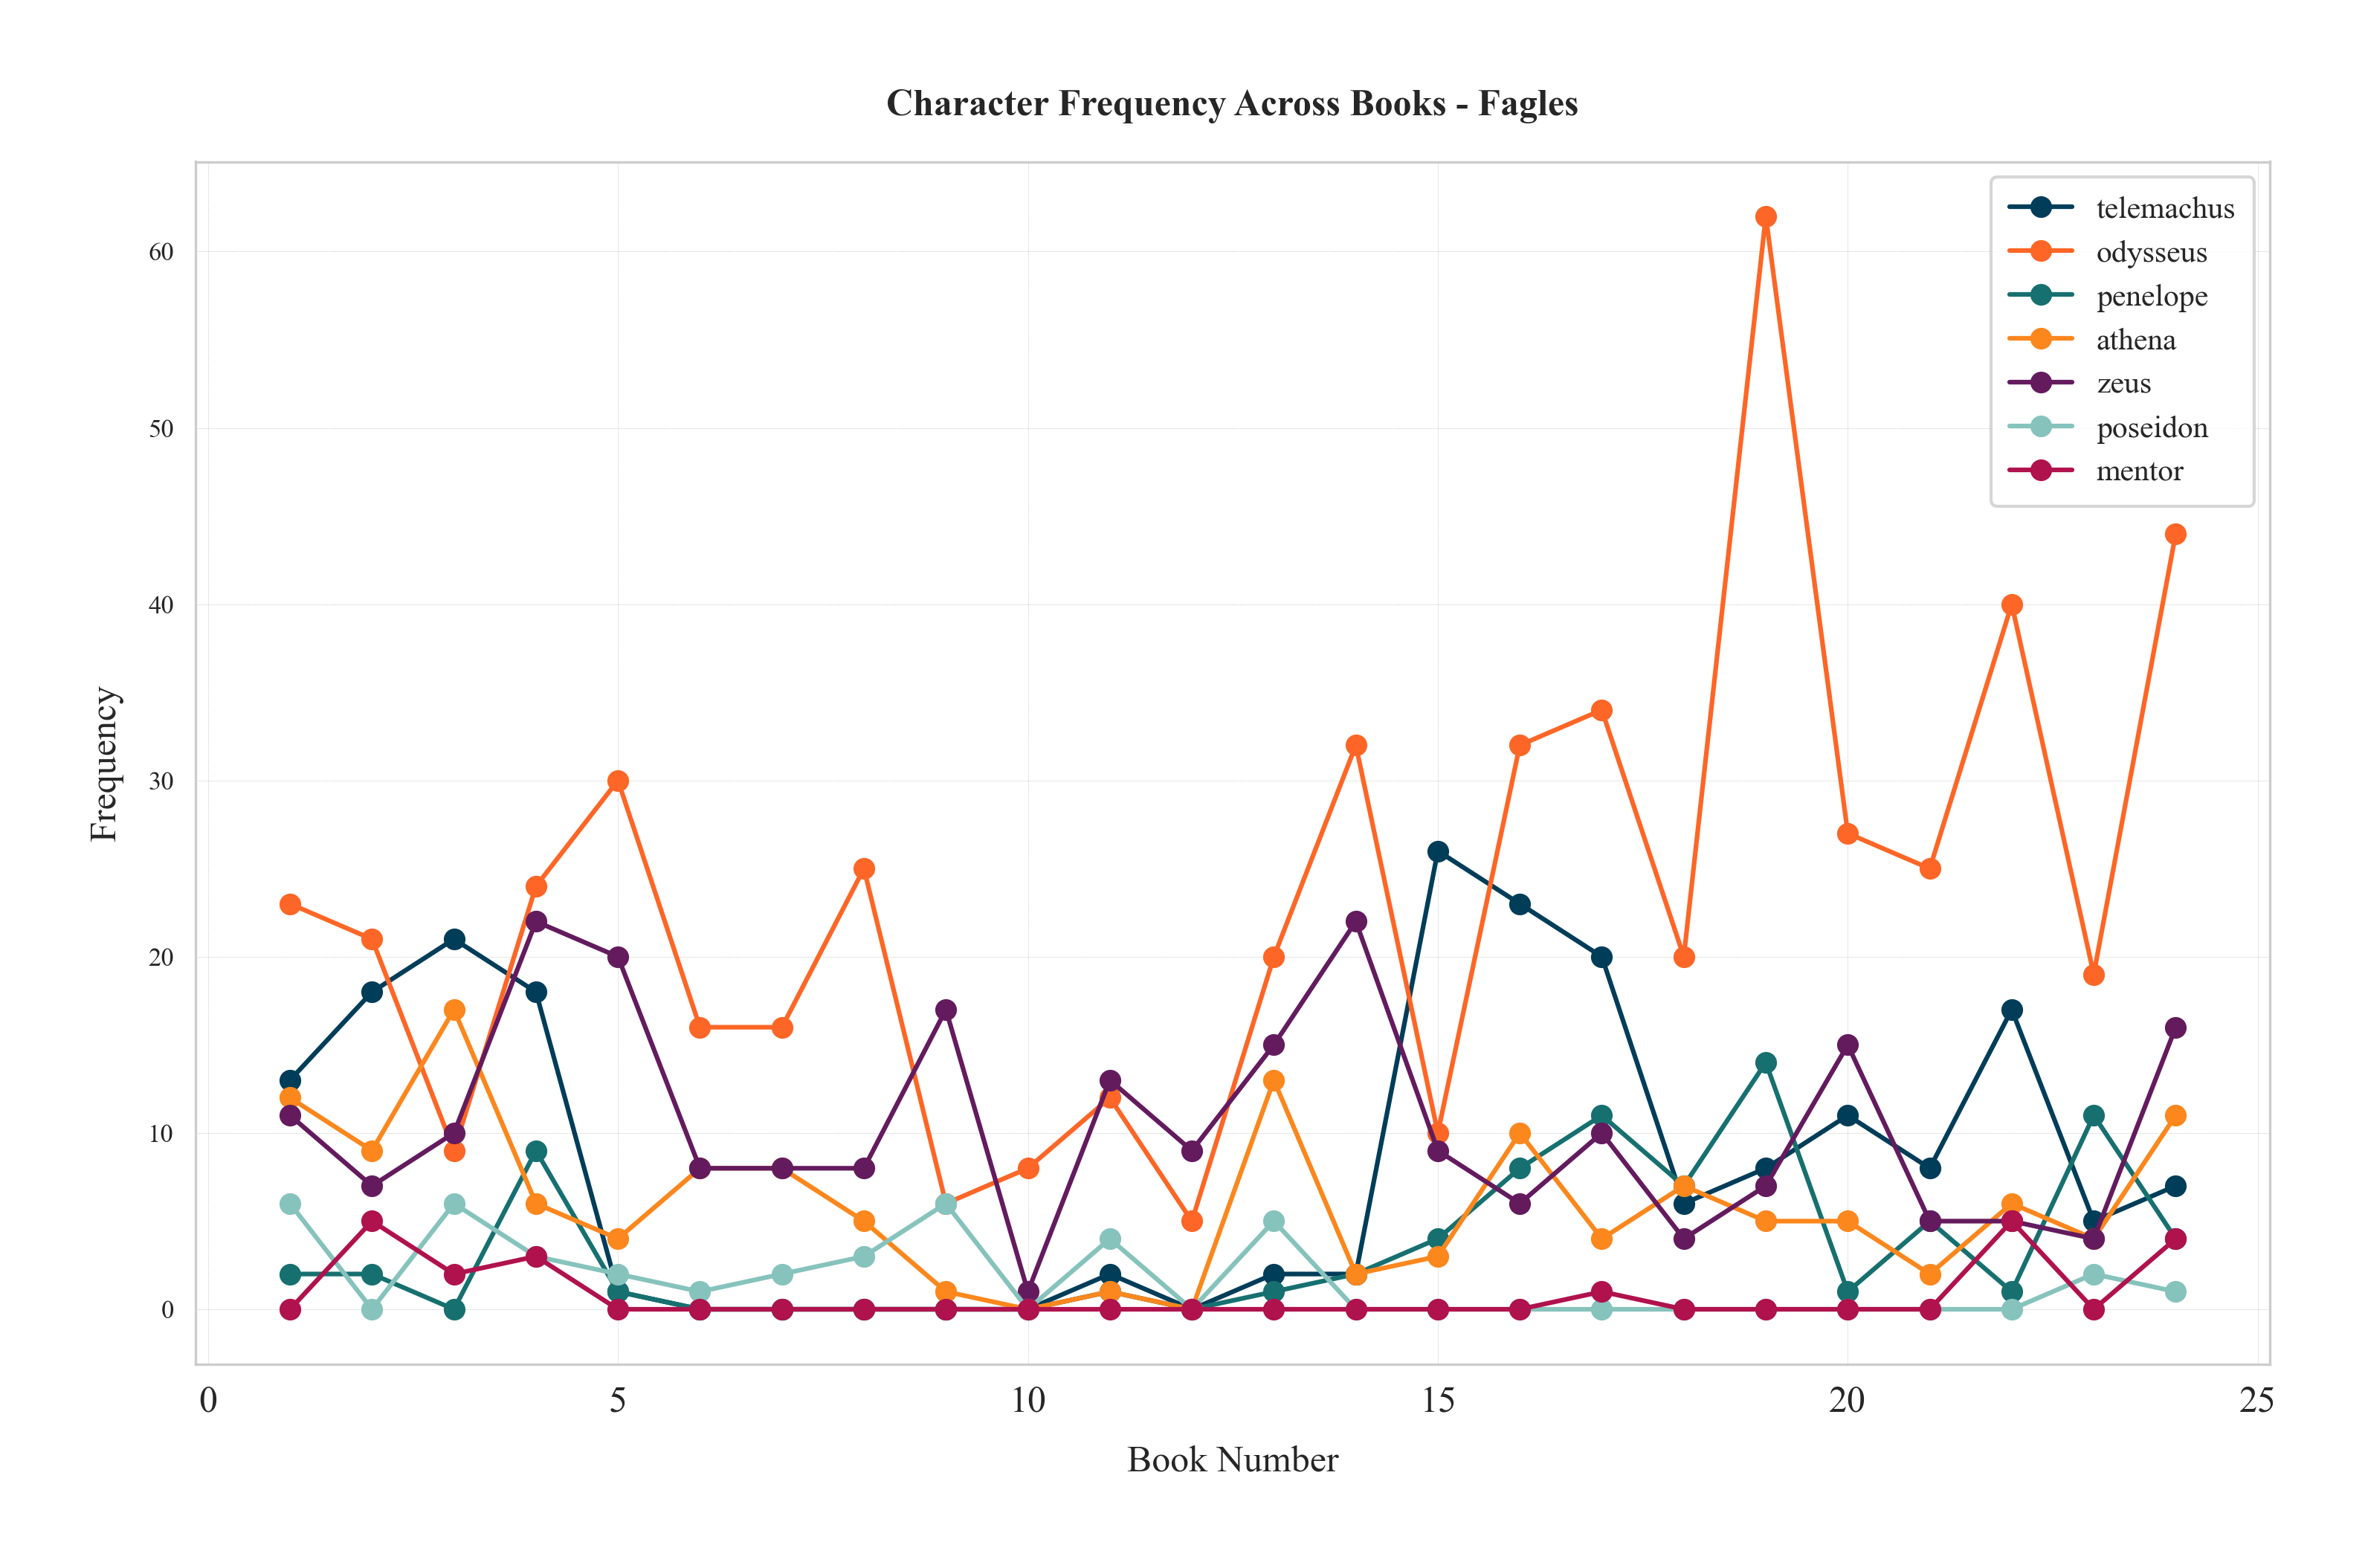

In [57]:
# Plot characters by relative freq 
characters = [ 'telemachus', 'odysseus', 'penelope', 'athena', 'zeus', 'poseidon', 'mentor']
freq_df = count_keywords_by(df, by='book_num', keywords=characters)
freq_df.plot(kind='line', figsize=(12, 7), marker='o')
plt.title(f'Character Frequency Across Books - {translator}')
plt.xlabel('Book Number')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()

Processing texts:   0%|          | 0/24 [00:00<?, ?it/s]

Processing texts:   0%|          | 0/10 [00:00<?, ?it/s]

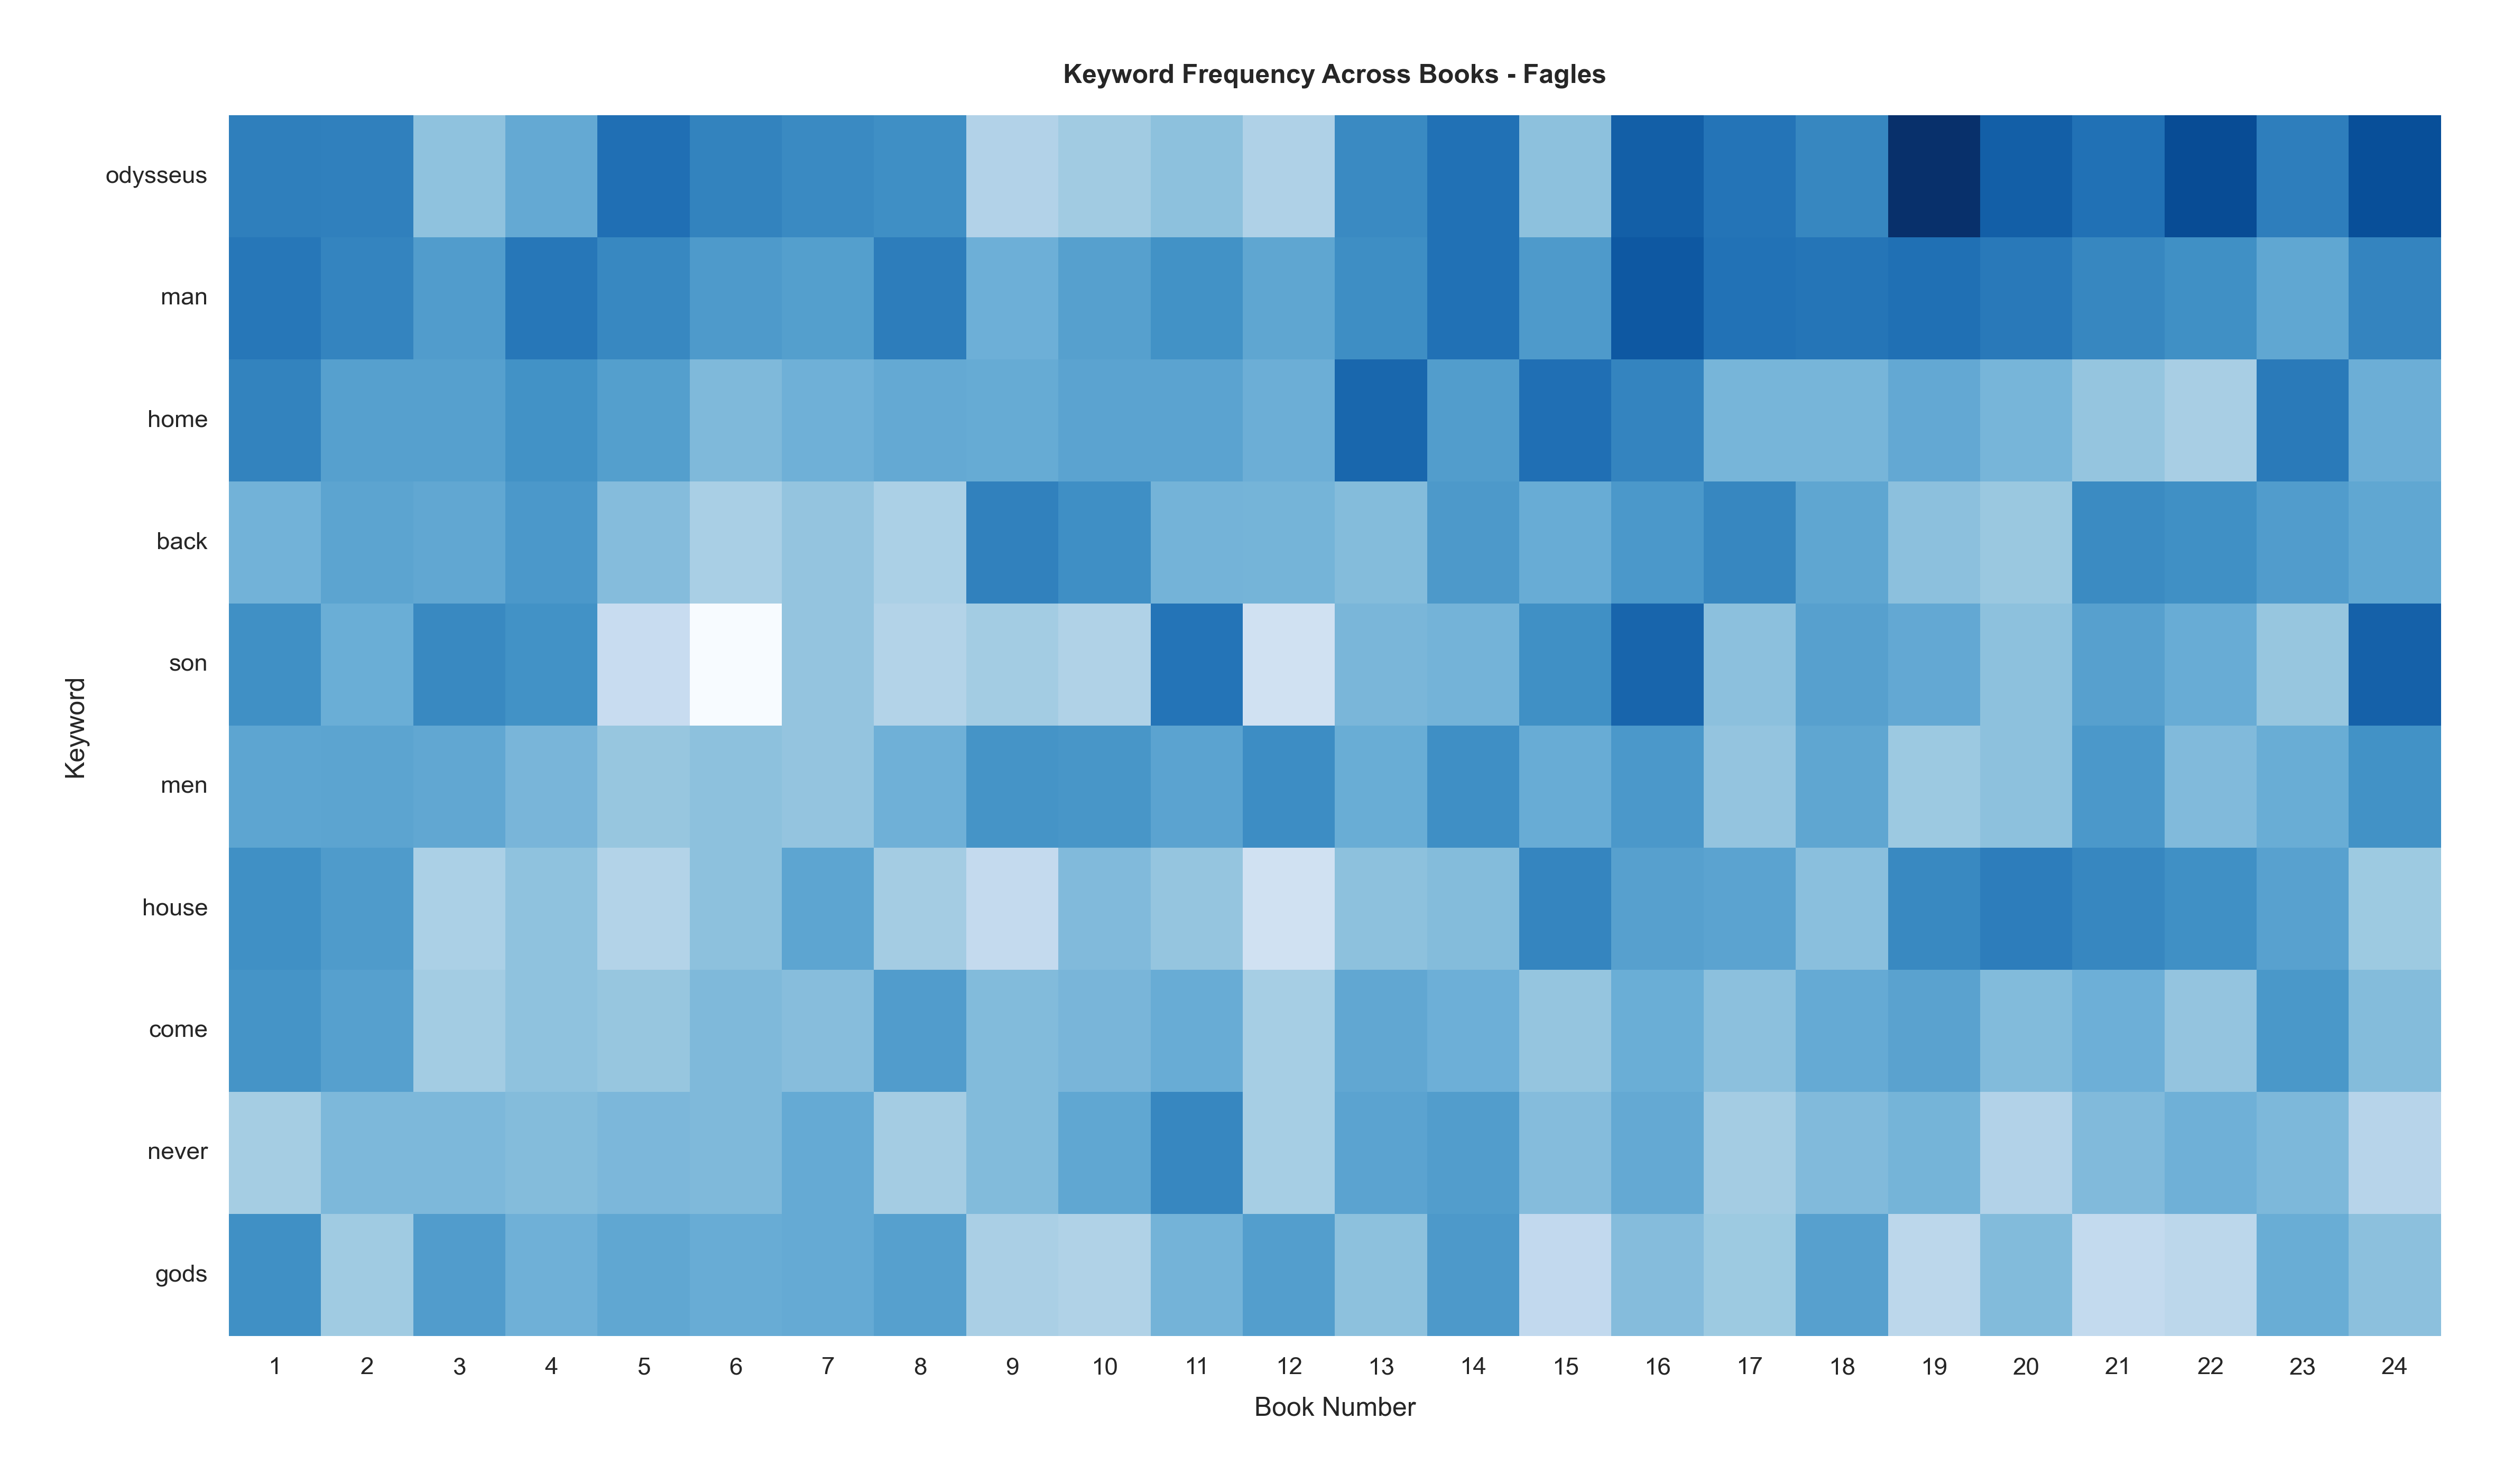

In [61]:
freq_df = count_keywords_by(df, by='book_num', keywords=keywords)

# compute relative frequencies based on total number of tokens per year
freq_df = freq_df.div(df.groupby('book_num')['num_tokens'].sum(), axis=0)
# apply square root as sublinear filter for better contrast
freq_df = freq_df.progress_apply(np.sqrt)

plt.figure(figsize=(18, 10)) ###
sns.set(font_scale=1) ###
# dark  ax=axs[1], cmap='gray'
sns.heatmap(data=freq_df.T, 
            xticklabels=True, yticklabels=True, cmap="Blues", cbar=False) # , cmap="Reds"

# rotate y labels
plt.yticks(rotation=0)
plt.title(f'Keyword Frequency Across Books - {translator}')
plt.xlabel('Book Number')
plt.ylabel('Keyword')
plt.savefig(f"{output_path_plots}/{translator}-Keyword_Frequency_Heatmap.png")
plt.show()

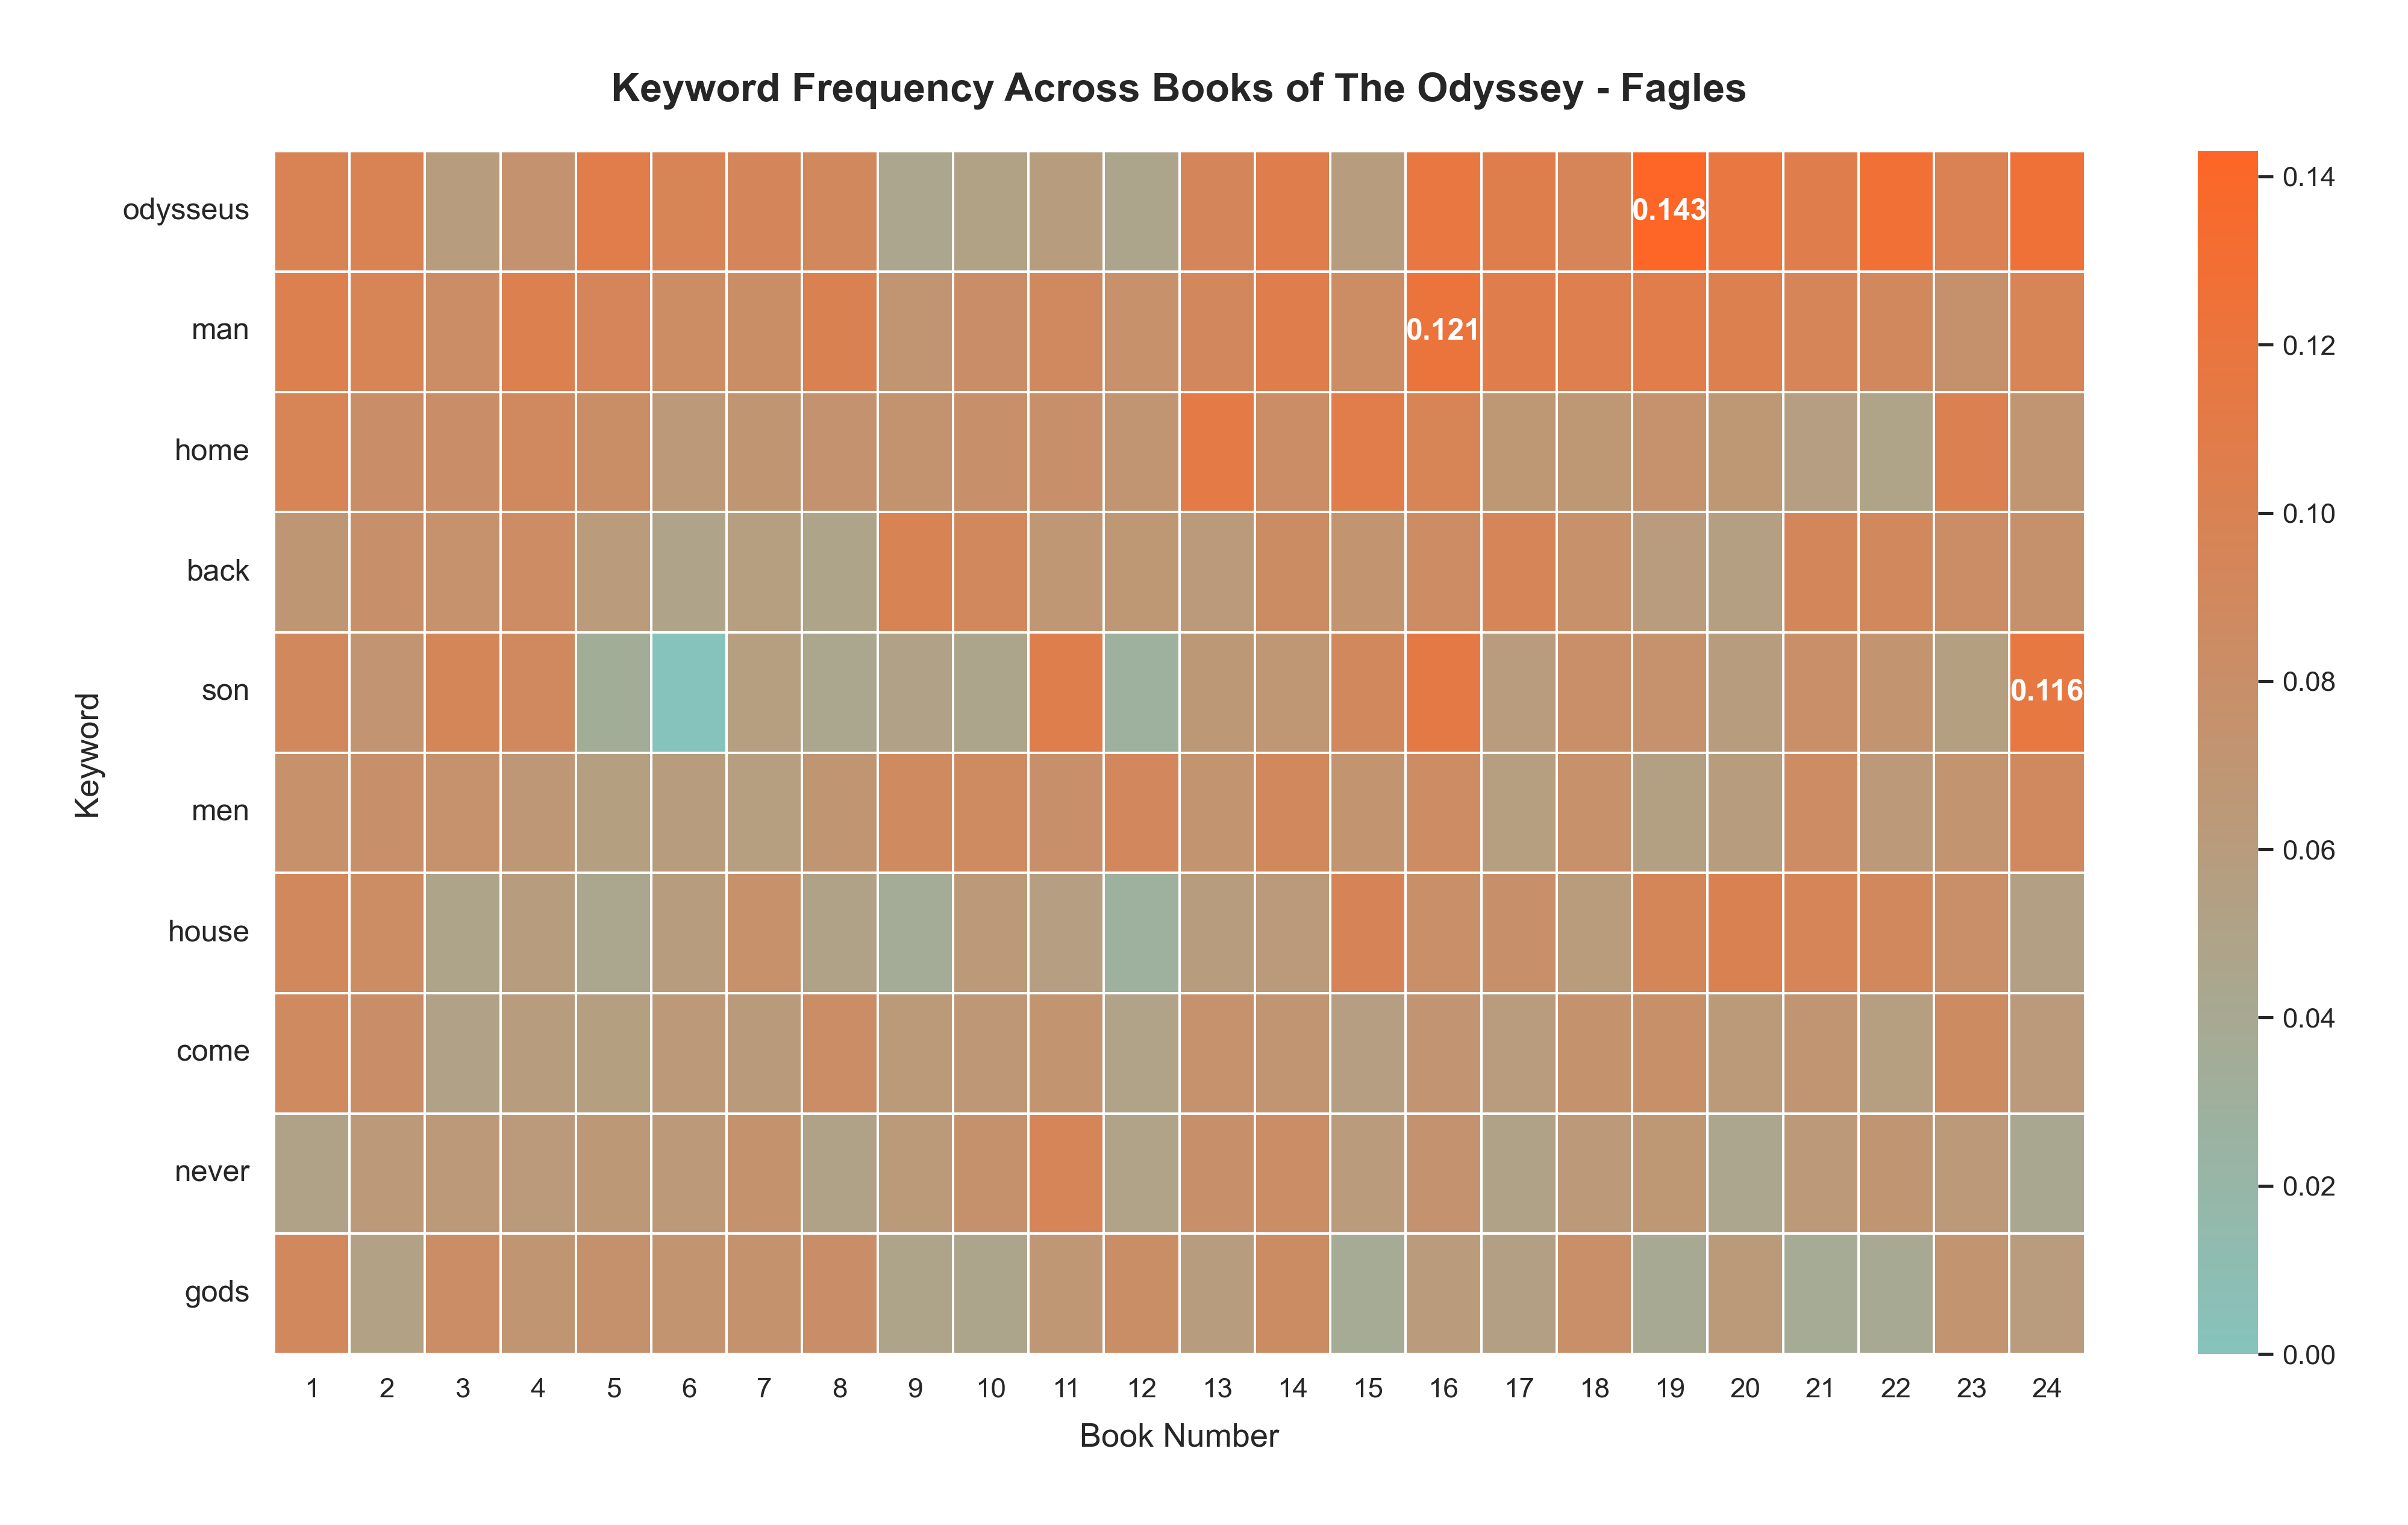

In [62]:
from matplotlib.colors import LinearSegmentedColormap

#keywords = list(freq_df.index)  # Get keywords from the dataframe index
# Your custom color palette
neptune = '#86C3BC'
astroblue = '#FD6626' #'#003D59'
custom_colors = ['#003D59', '#FD6626', '#177070', '#FB871D', '#641B5E', '#86C3BC', '#F5E1FD', '#414A4F', 'k']

# Create custom colormap
custom_cmap = LinearSegmentedColormap.from_list('neptune_blue', [neptune, astroblue])

# Create figure
plt.figure(figsize=(14, 8))

# Create the heatmap with improved aesthetics
ax = sns.heatmap(
    data=freq_df.T,
    vmin=0,
    vmax=freq_df.values.max(),
    cmap=custom_cmap,
    xticklabels=True, 
    yticklabels=True,
    cbar=True,
    linewidths=0.5,
    linecolor='white'
)
plt.yticks(rotation=0, fontsize=12)
plt.xticks(fontsize=11)
plt.title(f'Keyword Frequency Across Books of The Odyssey - {translator}',fontsize=16, pad=20)
plt.xlabel('Book Number', fontsize=13)
plt.ylabel('Keyword', fontsize=13)

# Add annotations for highest frequency words
for i in range(len(keywords)):
    max_idx = freq_df.T.iloc[i].argmax()
    max_val = freq_df.T.iloc[i, max_idx]
    if max_val > freq_df.values.max() * 0.8:  # Only annotate the most significant values
        ax.text(max_idx + 0.5, i + 0.5, f'{max_val:.3f}', 
                ha='center', va='center', color='white', fontweight='bold')

# Adjust layout
plt.tight_layout()
plt.savefig(f"{output_path_plots}/{translator}-Keyword_Frequency_Heatmap.png")
plt.show()

Processing texts:   0%|          | 0/24 [00:00<?, ?it/s]

Processing texts:   0%|          | 0/7 [00:00<?, ?it/s]

IndexError: single positional indexer is out-of-bounds

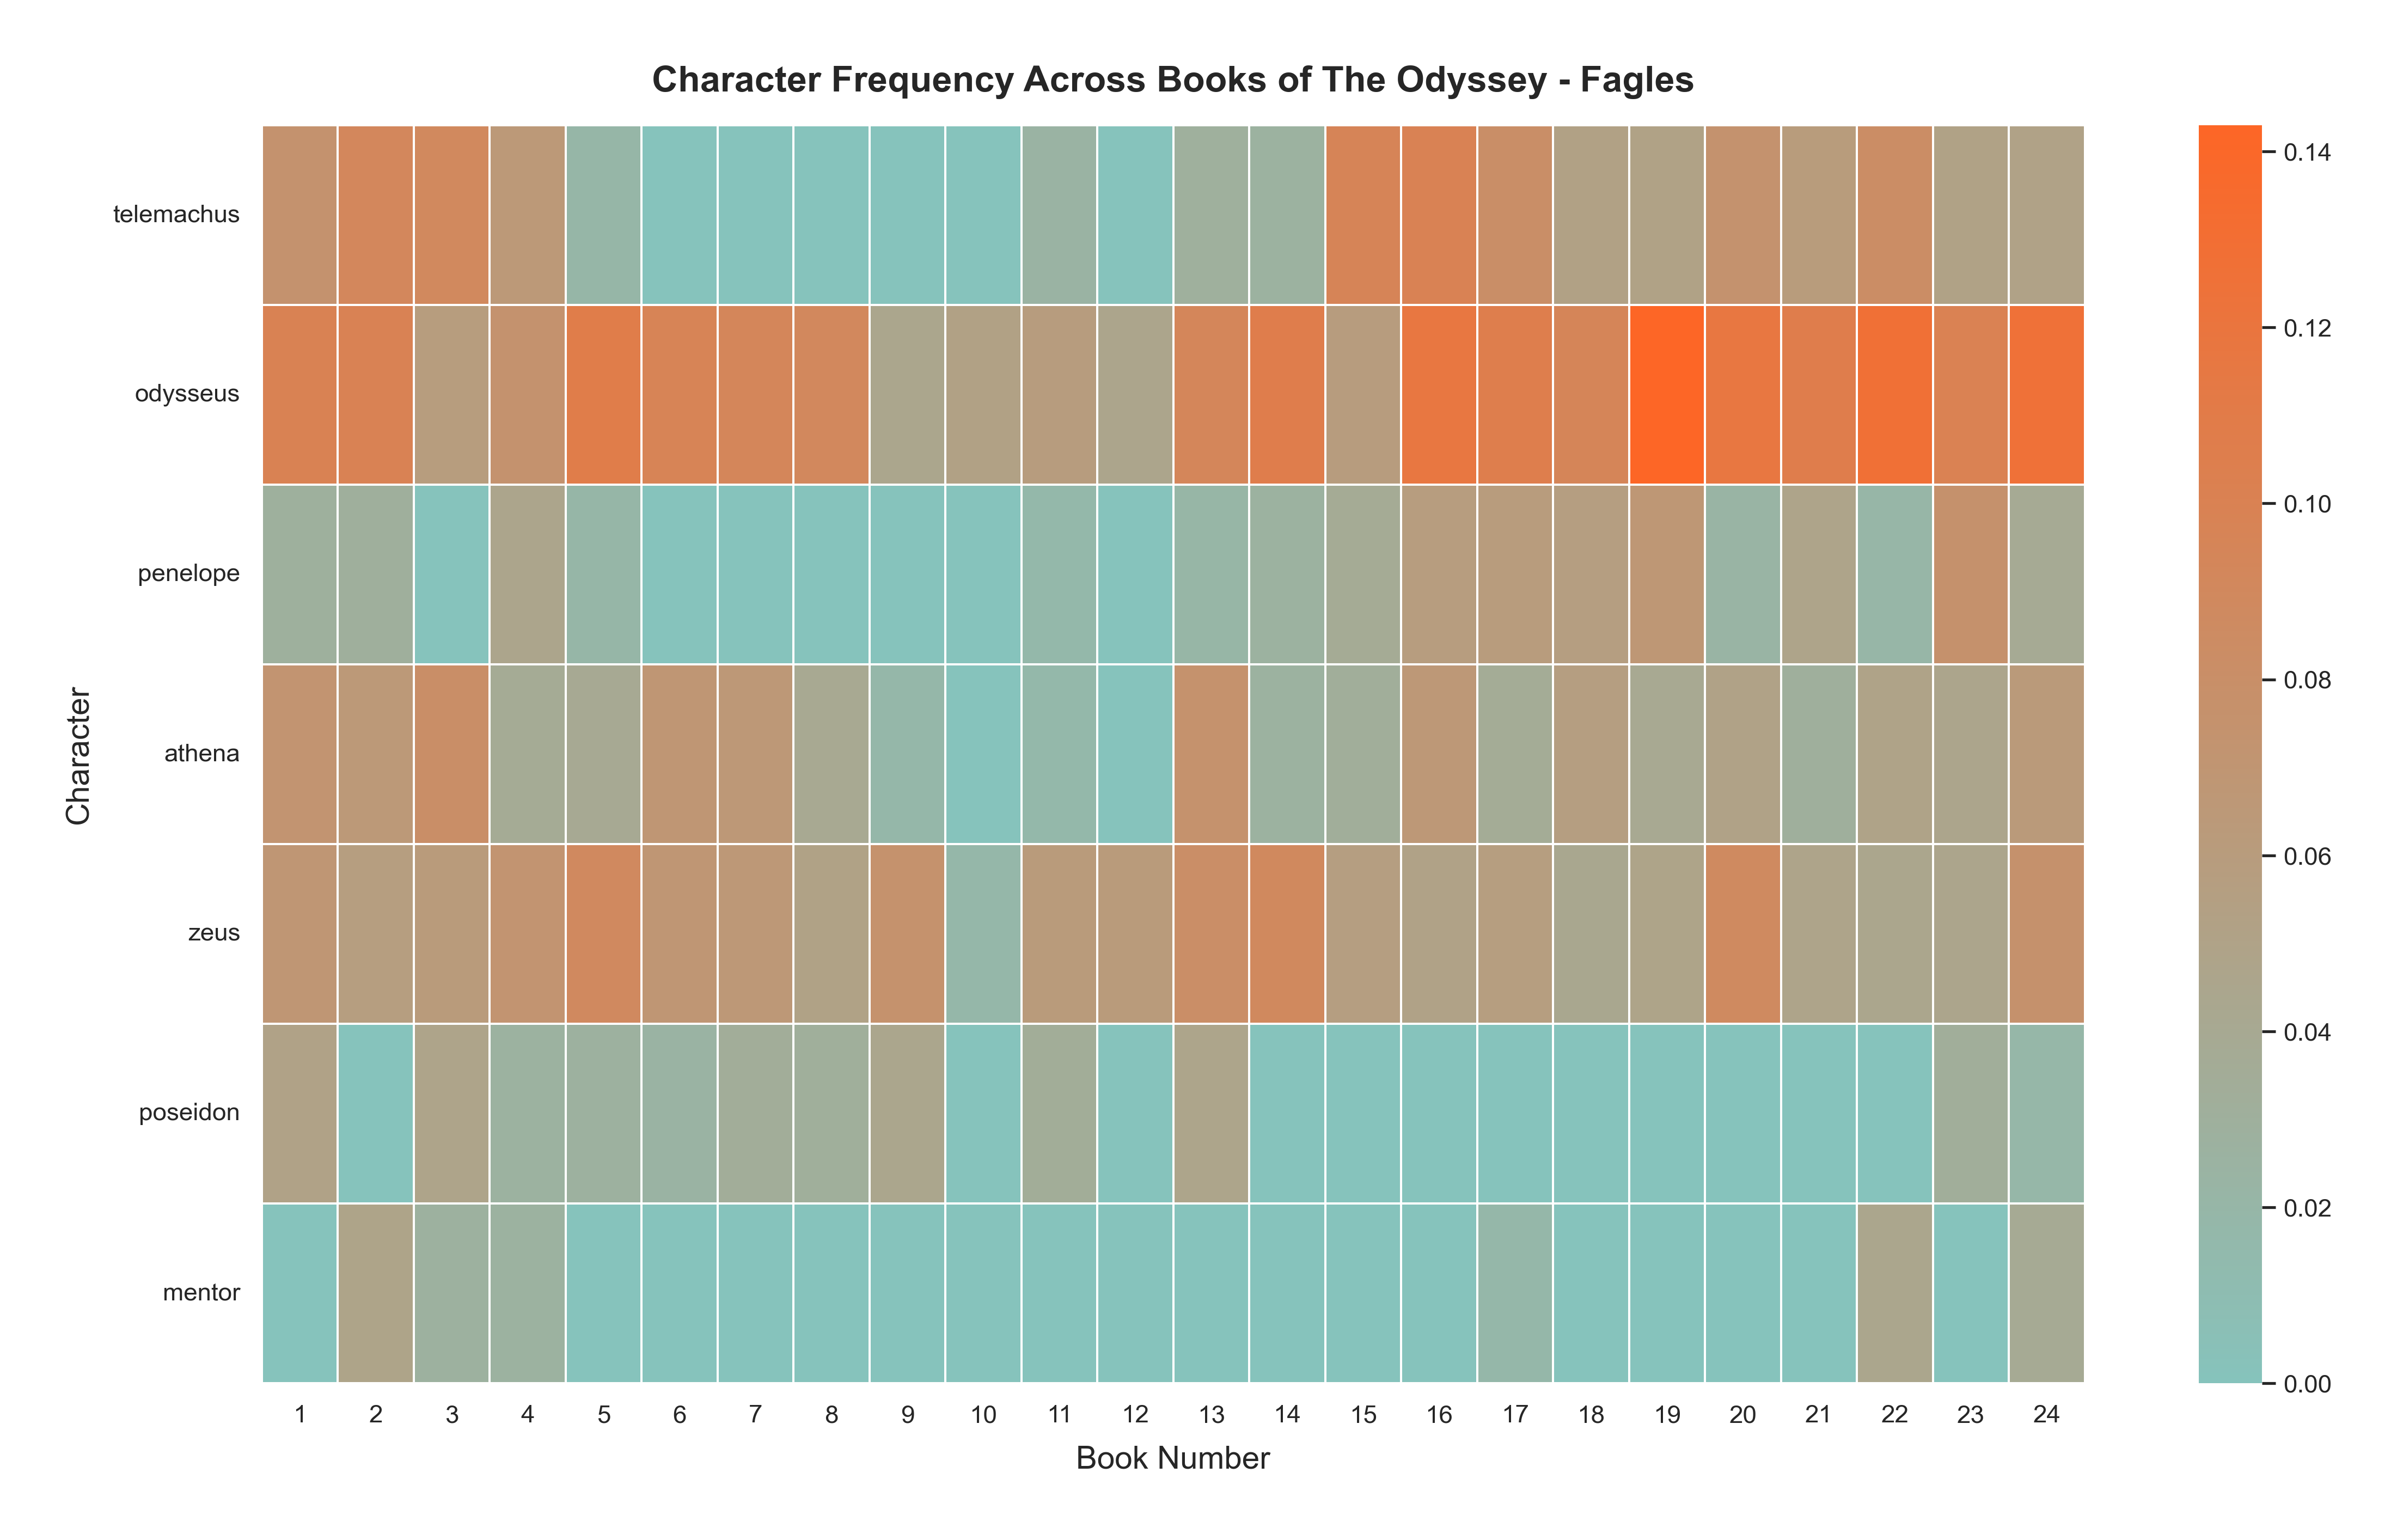

In [64]:
freq_df = count_keywords_by(df, by='book_num', keywords=characters)
# compute relative frequencies based on total number of tokens per year
freq_df = freq_df.div(df.groupby('book_num')['num_tokens'].sum(), axis=0)
# apply square root as sublinear filter for better contrast
freq_df = freq_df.progress_apply(np.sqrt)

# Define color scheme
neptune = '#86C3BC'
astroblue = '#FD6626'  # orange instead of blue
custom_colors = ['#003D59', '#FD6626', '#177070', '#FB871D', '#641B5E', '#86C3BC', '#F5E1FD', '#414A4F', 'k']
# Create custom colormap
custom_cmap = LinearSegmentedColormap.from_list('neptune_orange', [neptune, astroblue])

# Create plot with custom dimensions
plt.figure(figsize=(18, 10))

# Create the heatmap with custom aesthetics
ax = sns.heatmap(
    data=freq_df.T,
    vmin=0,
    vmax=freq_df.values.max(),
    cmap=custom_cmap,
    xticklabels=True,
    yticklabels=True,
    cbar=True,
    linewidths=0.5,
    linecolor='white'
)

# Format labels and title
plt.yticks(rotation=0)
plt.title(f'Character Frequency Across Books of The Odyssey - {translator}', fontsize=16)
plt.xlabel('Book Number', fontsize=14)
plt.ylabel('Character', fontsize=14)

# Add annotations for highest frequency words
for i in range(len(keywords)):
    max_idx = freq_df.T.iloc[i].argmax()
    max_val = freq_df.T.iloc[i, max_idx]
    if max_val > freq_df.values.max():  # Only annotate the most significant values
        ax.text(max_idx + 0.5, i + 0.5, f'{max_val:.3f}', 
                ha='center', va='center', color='white', fontweight='bold')

# Show the plot
plt.tight_layout()
plt.savefig(f"{output_path_plots}/{translator}-Character_Frequency_Heatmap.png")
plt.show()

### IDF

In [ ]:
# Inverse document frequency (IDF) is a measure of how unique a word is across documents.
# Words that appear in many documents have low IDF, while words that appear in few documents have high IDF.
# This can be useful for identifying keywords or important terms in a collection of texts.
def compute_idf(df, column='tokens', preprocess=None, min_df=2):
    """A fucntion to compute the inverse document frequency (IDF) of tokens in a data frame.

    Args:
        df (_type_):  
        column (str, optional): _description_. Defaults to 'tokens'.
        preprocess (_type_, optional): _description_. Defaults to None.
        min_df (int, optional): _description_. Defaults to 2.
    """

    def update(doc):
        tokens = doc if preprocess is None else preprocess(doc)
        counter.update(set(tokens))

    # count tokens
    counter = Counter()
    df[column].progress_map(update)

    # create data frame and compute idf
    idf_df = pd.DataFrame.from_dict(counter, orient='index', columns=['df'])
    idf_df = idf_df.query('df >= @min_df')
    idf_df['idf'] = np.log(len(df)/idf_df['df'])+0.1
    idf_df.index.name = 'token'
    return idf_df

idf_df = compute_idf(df)

In [ ]:
idf_df.sort_values('idf', ascending=False).head(10)

In [ ]:
idf_df.sample(10, random_state=42)

In [ ]:
idf_df.sample(10, random_state=40)

In [ ]:
# high IDF means rare (interesting) term
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)###
wordcloud(idf_df['idf'], title='IDF', max_words=100)
plt.subplot(1,2,2)###
wordcloud(idf_df['idf'], title='IDF', max_words=100, stopwords=idf_df.query('idf < 2').index)
plt.tight_layout()###
plt.show()


In [ ]:
# not in book: for more data: joining is faster
freq_df = freq_df.join(idf_df)
freq_df['tfidf'] = freq_df['freq'] * freq_df['idf']

In [ ]:
freq_1 = count_words(df[df['book_num'] == 1])
freq_2 = count_words(df[df['book_num'] == 2])

freq_1['tfidf'] = freq_1['freq'] * idf_df['idf']
freq_2['tfidf'] = freq_2['freq'] * idf_df['idf']

plt.figure(figsize=(12,6)) ###
#wordcloud(freq_df['freq'], title='All years', subplot=(1,3,1))
plt.subplot(2,2,1)###
wordcloud(freq_1['freq'], title='B1 - TF',
          stopwords=[''])
plt.subplot(2,2,2)###
wordcloud(freq_1['tfidf'], title='B1 - TF-IDF',
          stopwords=[''])
plt.subplot(2,2,3)###
wordcloud(freq_2['freq'], title='B2 - TF',
          stopwords=[''])
plt.subplot(2,2,4)###
wordcloud(freq_2['tfidf'], title='B2 - TF-IDF',
          stopwords=[''])
plt.tight_layout()###
plt.savefig(f"{output_path_plots}/{translator}-TF_TFIDF_wordcloud_B1-2.png")

### Keyword Window

In [43]:
# From Blueprints for Text Analysis Using Python
# by Matthew Russell
# Published by O'Reilly Media, Inc., 2021
import textacy

if textacy.__version__ < '0.11': # as in printed book
    from textacy.text_utils import KWIC

else: # for textacy 0.11.x
    from textacy.extract.kwic import keyword_in_context

    def KWIC(*args, **kwargs):
        # call keyword_in_context with all params except 'print_only'
        return keyword_in_context(*args,
                           **{kw: arg for kw, arg in kwargs.items()
                            if kw != 'print_only'})

def kwic(doc_series, keyword, window=35, print_samples=5):

    def add_kwic(text):
        kwic_list.extend(KWIC(text, keyword, ignore_case=True,
                              window_width=window, print_only=False))

    kwic_list = []
    doc_series.progress_map(add_kwic)

    if print_samples is None or print_samples==0:
        return kwic_list
    else:
        k = min(print_samples, len(kwic_list))
        print(f"{k} random samples out of {len(kwic_list)} " + \
              f"contexts for '{keyword}':")
        for sample in random.sample(list(kwic_list), k):
            print(re.sub(r'[\n\t]', ' ', sample[0])+'  '+ \
                  sample[1]+'  '+\
                  re.sub(r'[\n\t]', ' ', sample[2]))

In [44]:
import random
random.seed(22)
keyword = 'spear'
kwic(df['text'], keyword, print_samples=10)


Processing texts:   0%|          | 0/24 [00:00<?, ?it/s]

10 random samples out of 75 contexts for 'spear':
etched our curved bows and hunting   spear  s from the ships and, splitting up 
shield from my back and dropped my   spear   and ran right into the path of the
 pillar, there where row on row of   spear  s, embattled Odysseus’ spears, stoo
s sharp sword on, clamping hand to   spear  , took his stand by a chair that fl
 of battle dead, stabbed by bronze   spear  s, men of war still wrapped in bloo
 victors, just behind her, digging   spear  -butts into her back and shoulders,
 And just then Piraeus the gallant   spear  man approached, leading the strange
 age at home, his sons expert with   spear  s and full of sense. Well, so much 
ar out of the front I’d charge and   spear   my man, I’d cut down any enemy sol
, Telemachus,” Piraeus the gallant   spear  man offered warmly: “Stay up-countr


In [ ]:
# Find keyword in a specific book
kwic(df[df['book_num'] == 5]['text'], 'water', print_samples=10)

Processing texts:   0%|          | 0/1 [00:00<?, ?it/s]

7 random samples out of 7 contexts for 'water':
yself will stock her with food and   water  , ruddy wine to your taste—all to s
k wine in one, the larger one held   water  —added a sack of rations, filled wi
he heavy breaking seas like a shear  water   once again— and a dark heaving bil
g Sky above and the dark cascading   water  s of the Styx—I swear by the greate
es, now I’ve crossed this waste of   water  , the end in sight, there’s no way 
e broke from the waves like a shear  water   on the wing, lit on the wreck and 
for the woods and not far from the   water   found a grove with a clearing all 


## Bigrams

In [ ]:
def ngrams(tokens, n=2, sep=' ', stopwords=set()):
    return [sep.join(ngram) for ngram in zip(*[tokens[i:] for i in range(n)])
            if len([t for t in ngram if t in stopwords])==0]

df['bigrams'] = df['tokens'].progress_apply(ngrams, n=2, stopwords=stopwords)

count_words(df, 'bigrams').head(30)

In [ ]:
# recompute IDF with bigrams

idf_df = compute_idf(df) ### re-initialize to be safe
# concatenate existing IDF data frame with bigram IDFs
idf_df = pd.concat([idf_df, compute_idf(df, 'bigrams', min_df=10)])

freq_df = count_words(df[df['book_num'] == 4], 'bigrams')
freq_df['tfidf'] = freq_df['freq'] * idf_df['idf']

plt.figure(figsize=(12,6))
plt.subplot(1,2,1) ###
wordcloud(freq_df['tfidf'], title='all bigrams', max_words=50)

plt.subplot(1,2,2) ###
# plt.tight_layout() ###
where = freq_df.index.str.contains('words', case=False)
wordcloud(freq_df[where]['freq'], title='"words" bigrams', max_words=50)
plt.savefig(f"{output_path_plots}/{translator}-TFIDF_bigrams.png")
plt.show()

## Counting keywords

In [ ]:
def count_keywords(tokens, keywords):
    tokens = [t for t in tokens if t in keywords]
    counter = Counter(tokens)
    return [counter.get(k, 0) for k in keywords]

In [ ]:
def count_keywords_by(df, by, keywords, column='tokens'):

    df = df.reset_index(drop=True) # if the supplied dataframe has gaps in the index
    freq_matrix = df[column].progress_apply(count_keywords, keywords=keywords)
    freq_df = pd.DataFrame.from_records(freq_matrix, columns=keywords)
    freq_df[by] = df[by] # copy the grouping column(s)

    return freq_df.groupby(by=by).sum().sort_values(by)

keywords = ['ship', 'words', 'sea', 'odysseus', 'spear', 'death', 'home', 'wine']
freq_df = count_keywords_by(df, 'book_num', keywords)

In [ ]:
pd.options.display.max_rows = 20
freq_df

In [ ]:
freq_df.plot(kind='line', figsize=(12, 7), marker='o')
plt.title(f'Keyword Frequency Across Books — {translator}')
plt.xlabel('Book Number')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.savefig(f"/Users/debr/English-Homer/EDA_by_Author/{translator}_EDA/plots/{translator}-Keyword_Frequency.png")
plt.show()

In [ ]:
# Plot characters by relative freq 
characters = [ 'poseidon','athene', 'zeus', 'telemachos', 'penelope', 'odysseus', 'mentor', 'agamemnon', 'achilles']
freq_df = count_keywords_by(df, by='book_num', keywords=characters)
freq_df.plot(kind='line', figsize=(12, 7), marker='o')
plt.title(f'Character Frequency Across Books - {translator}')
plt.xlabel('Book Number')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
keywords = ['ship', 'words', 'sea', 'odysseus', 'spear', 'death', 'home', 'wine']

freq_df = count_keywords_by(df, by='book_num', keywords=keywords)

# compute relative frequencies based on total number of tokens per year
freq_df = freq_df.div(df.groupby('book_num')['num_tokens'].sum(), axis=0)
# apply square root as sublinear filter for better contrast
freq_df = freq_df.progress_apply(np.sqrt)

plt.figure(figsize=(18, 10)) ###
sns.set(font_scale=1) ###
# dark  ax=axs[1], cmap='gray'
sns.heatmap(data=freq_df.T, 
            xticklabels=True, yticklabels=True, cmap="Reds", cbar=False) # , cmap="Reds"

# rotate y labels
plt.yticks(rotation=0)
plt.title(f'Keyword Frequency Across Books - {translator}')
plt.xlabel('Book Number')
plt.ylabel('Keyword')
plt.savefig(f"{output_path_plots}/{translator}-Keyword_Frequency_Heatmap.png")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

#keywords = list(freq_df.index)  # Get keywords from the dataframe index
# Your custom color palette
neptune = '#86C3BC'
astroblue = '#FD6626' #'#003D59'
custom_colors = ['#003D59', '#FD6626', '#177070', '#FB871D', '#641B5E', '#86C3BC', '#F5E1FD', '#414A4F', 'k']

# Create custom colormap
custom_cmap = LinearSegmentedColormap.from_list('neptune_blue', [neptune, astroblue])

# Create figure
plt.figure(figsize=(14, 8))

# Create the heatmap with improved aesthetics
ax = sns.heatmap(
    data=freq_df.T,
    vmin=0,
    vmax=freq_df.values.max(),
    cmap=custom_cmap,
    xticklabels=True, 
    yticklabels=True,
    cbar=True,
    linewidths=0.5,
    linecolor='white'
)
plt.yticks(rotation=0, fontsize=12)
plt.xticks(fontsize=11)
plt.title(f'Keyword Frequency Across Books of The Odyssey - {translator}',fontsize=16, pad=20)
plt.xlabel('Book Number', fontsize=13)
plt.ylabel('Keyword', fontsize=13)

# Add annotations for highest frequency words
for i in range(len(keywords)):
    max_idx = freq_df.T.iloc[i].argmax()
    max_val = freq_df.T.iloc[i, max_idx]
    if max_val > freq_df.values.max() * 0.8:  # Only annotate the most significant values
        ax.text(max_idx + 0.5, i + 0.5, f'{max_val:.3f}', 
                ha='center', va='center', color='white', fontweight='bold')

# Adjust layout
plt.tight_layout()
plt.savefig(f"{output_path_plots}/{translator}-Keyword_Frequency_Heatmap.png")
plt.show()

In [ ]:
# Define keywords and process them
characters = [ 'poseidon','athena', 'zeus', 'telemachus', 'penelope', 'odysseus', 'mentor', 'agamemnon', 'achilles']
freq_df = count_keywords_by(df, by='book_num', keywords=characters)
# compute relative frequencies based on total number of tokens per year
freq_df = freq_df.div(df.groupby('book_num')['num_tokens'].sum(), axis=0)
# apply square root as sublinear filter for better contrast
freq_df = freq_df.progress_apply(np.sqrt)

# Define color scheme
neptune = '#86C3BC'
astroblue = '#FD6626'  # orange instead of blue
custom_colors = ['#003D59', '#FD6626', '#177070', '#FB871D', '#641B5E', '#86C3BC', '#F5E1FD', '#414A4F', 'k']
# Create custom colormap
custom_cmap = LinearSegmentedColormap.from_list('neptune_orange', [neptune, astroblue])

# Create plot with custom dimensions
plt.figure(figsize=(18, 10))

# Create the heatmap with custom aesthetics
ax = sns.heatmap(
    data=freq_df.T,
    vmin=0,
    vmax=freq_df.values.max(),
    cmap=custom_cmap,
    xticklabels=True,
    yticklabels=True,
    cbar=True,
    linewidths=0.5,
    linecolor='white'
)

# Format labels and title
plt.yticks(rotation=0)
plt.title(f'Character Frequency Across Books of The Odyssey - {translator}', fontsize=16)
plt.xlabel('Book Number', fontsize=14)
plt.ylabel('Character', fontsize=14)

# Show the plot
plt.tight_layout()
plt.savefig(f"{output_path_plots}/{translator}-Character_Frequency_Heatmap.png")
plt.show()

In [ ]:
# save the dataframe in a csv file outside the project to avoid infringment
df.to_csv(f'/Users/debr/odysseys_en/Odyssey_dfs/Odyssey_{translator}_eda_END.csv', index=False)